In [1]:
import warnings;
warnings.simplefilter('ignore')
from dcr import *

In [2]:
%matplotlib inline
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (16,9)
plt.rcParams.update({'font.size': 16})

In [3]:
from dcr import * 
data, _, _, _, _, _, _ = dataprep(data)

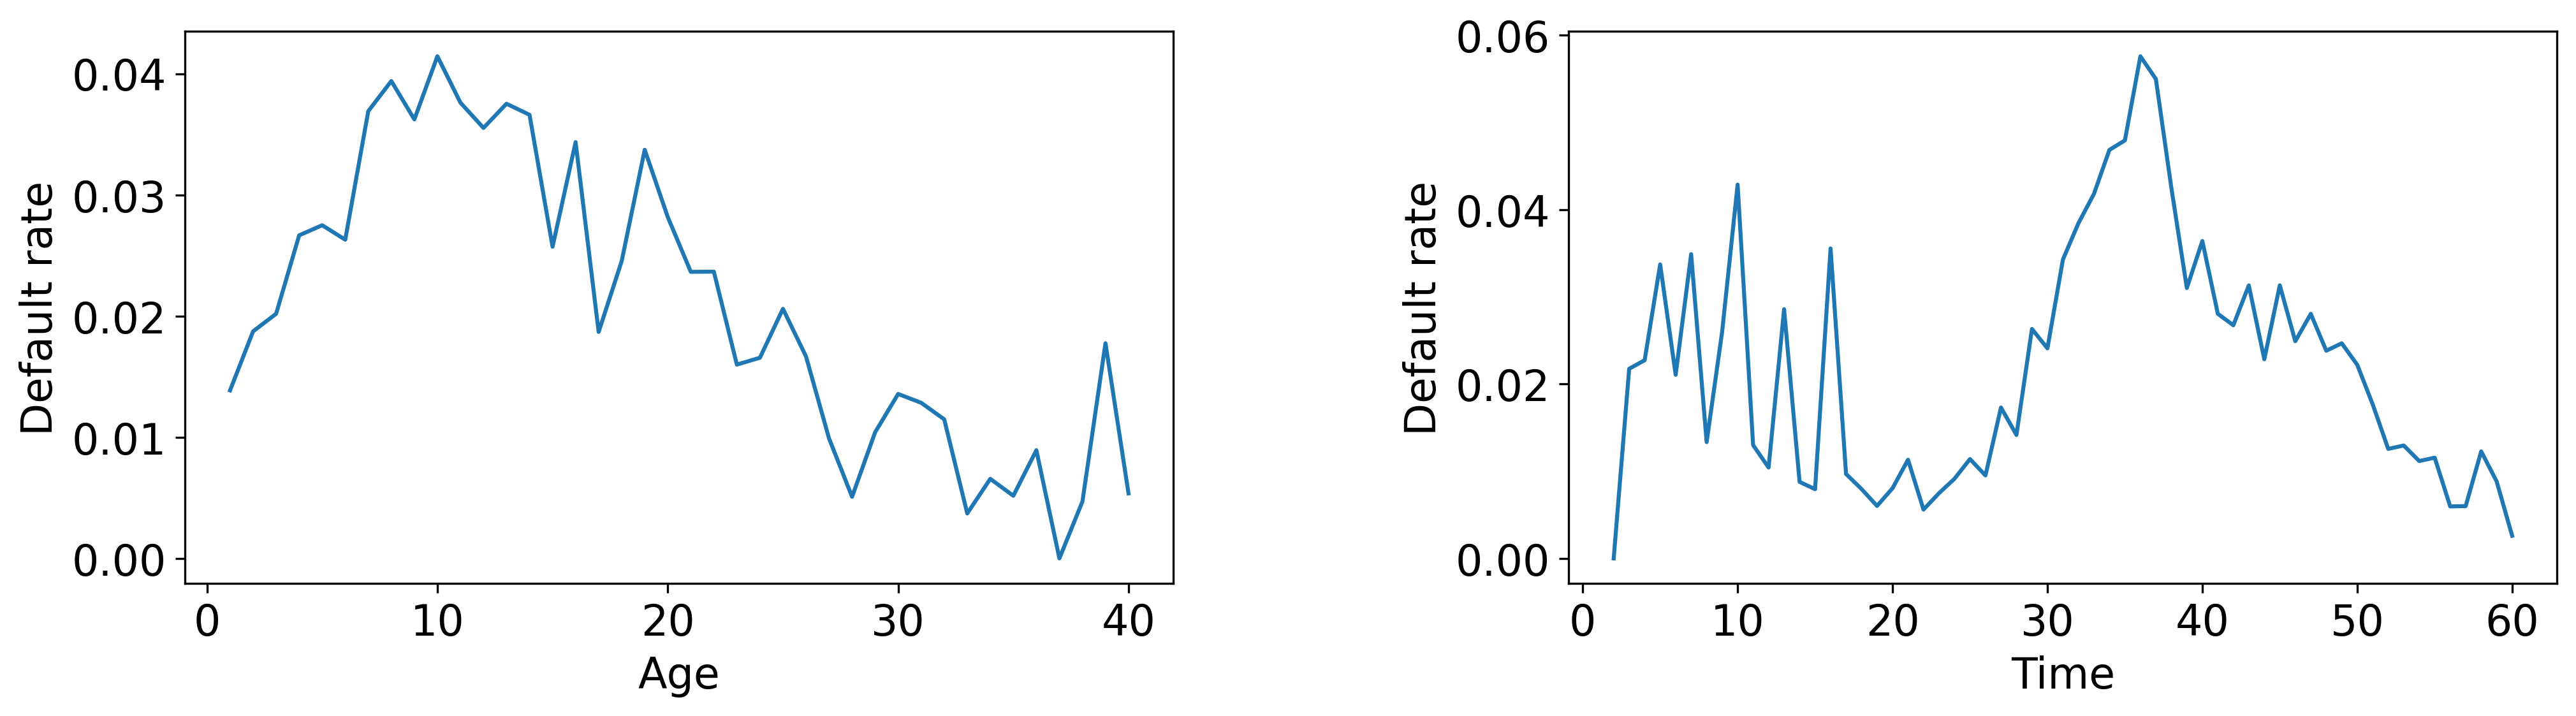

In [4]:
data_mean_age = data.groupby('age')[['age','default_time']].mean()
data_mean_time = data.groupby('time')[['time','default_time']].mean()

plt.subplots_adjust(hspace=0.4, wspace=0.4)

plt.subplot(221)
plt.plot('age', 'default_time', data=data_mean_age, label='Default rate')
plt.xlabel('Age')
plt.ylabel('Default rate')

plt.subplot(222)
plt.plot('time', 'default_time', data=data_mean_time, label='Default rate')
plt.xlabel('Time')
plt.ylabel('Default rate')
plt.show()

In [7]:
model_lr = smf.glm('default_time ~ cep_time + equity_time + interest_rate_time + FICO_orig_time + gdp_time + PCA1_1 + PCA2_1 + PCA3_1 + PCA4_1 + PCA5_1 + cluster_1 + age + age2',
                   family = sm.families.Binomial(), data = data).fit()

print(model_lr.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:           default_time   No. Observations:                59001
Model:                            GLM   Df Residuals:                    58987
Model Family:                Binomial   Df Model:                           13
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -6398.5
Date:                Mon, 25 Aug 2025   Deviance:                       12797.
Time:                        09:38:42   Pearson chi2:                 5.61e+04
No. Iterations:                     8   Pseudo R-squ. (CS):            0.01592
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -2.3212      0

In [8]:
PD_logit_model = pd.DataFrame(model_lr.fittedvalues, columns = ['PD_probit_model'])

data2 = pd.merge(data, PD_logit_model, right_index=True, left_index=True)

data2_mean_age = data2.groupby('age')[['default_time','PD_probit_model']].mean()
data2_mean_time = data2.groupby('time')[['default_time','PD_probit_model']].mean()

data2_mean_age = data2_mean_age.reset_index(drop=False)
data2_mean_time = data2_mean_time.reset_index(drop=False)

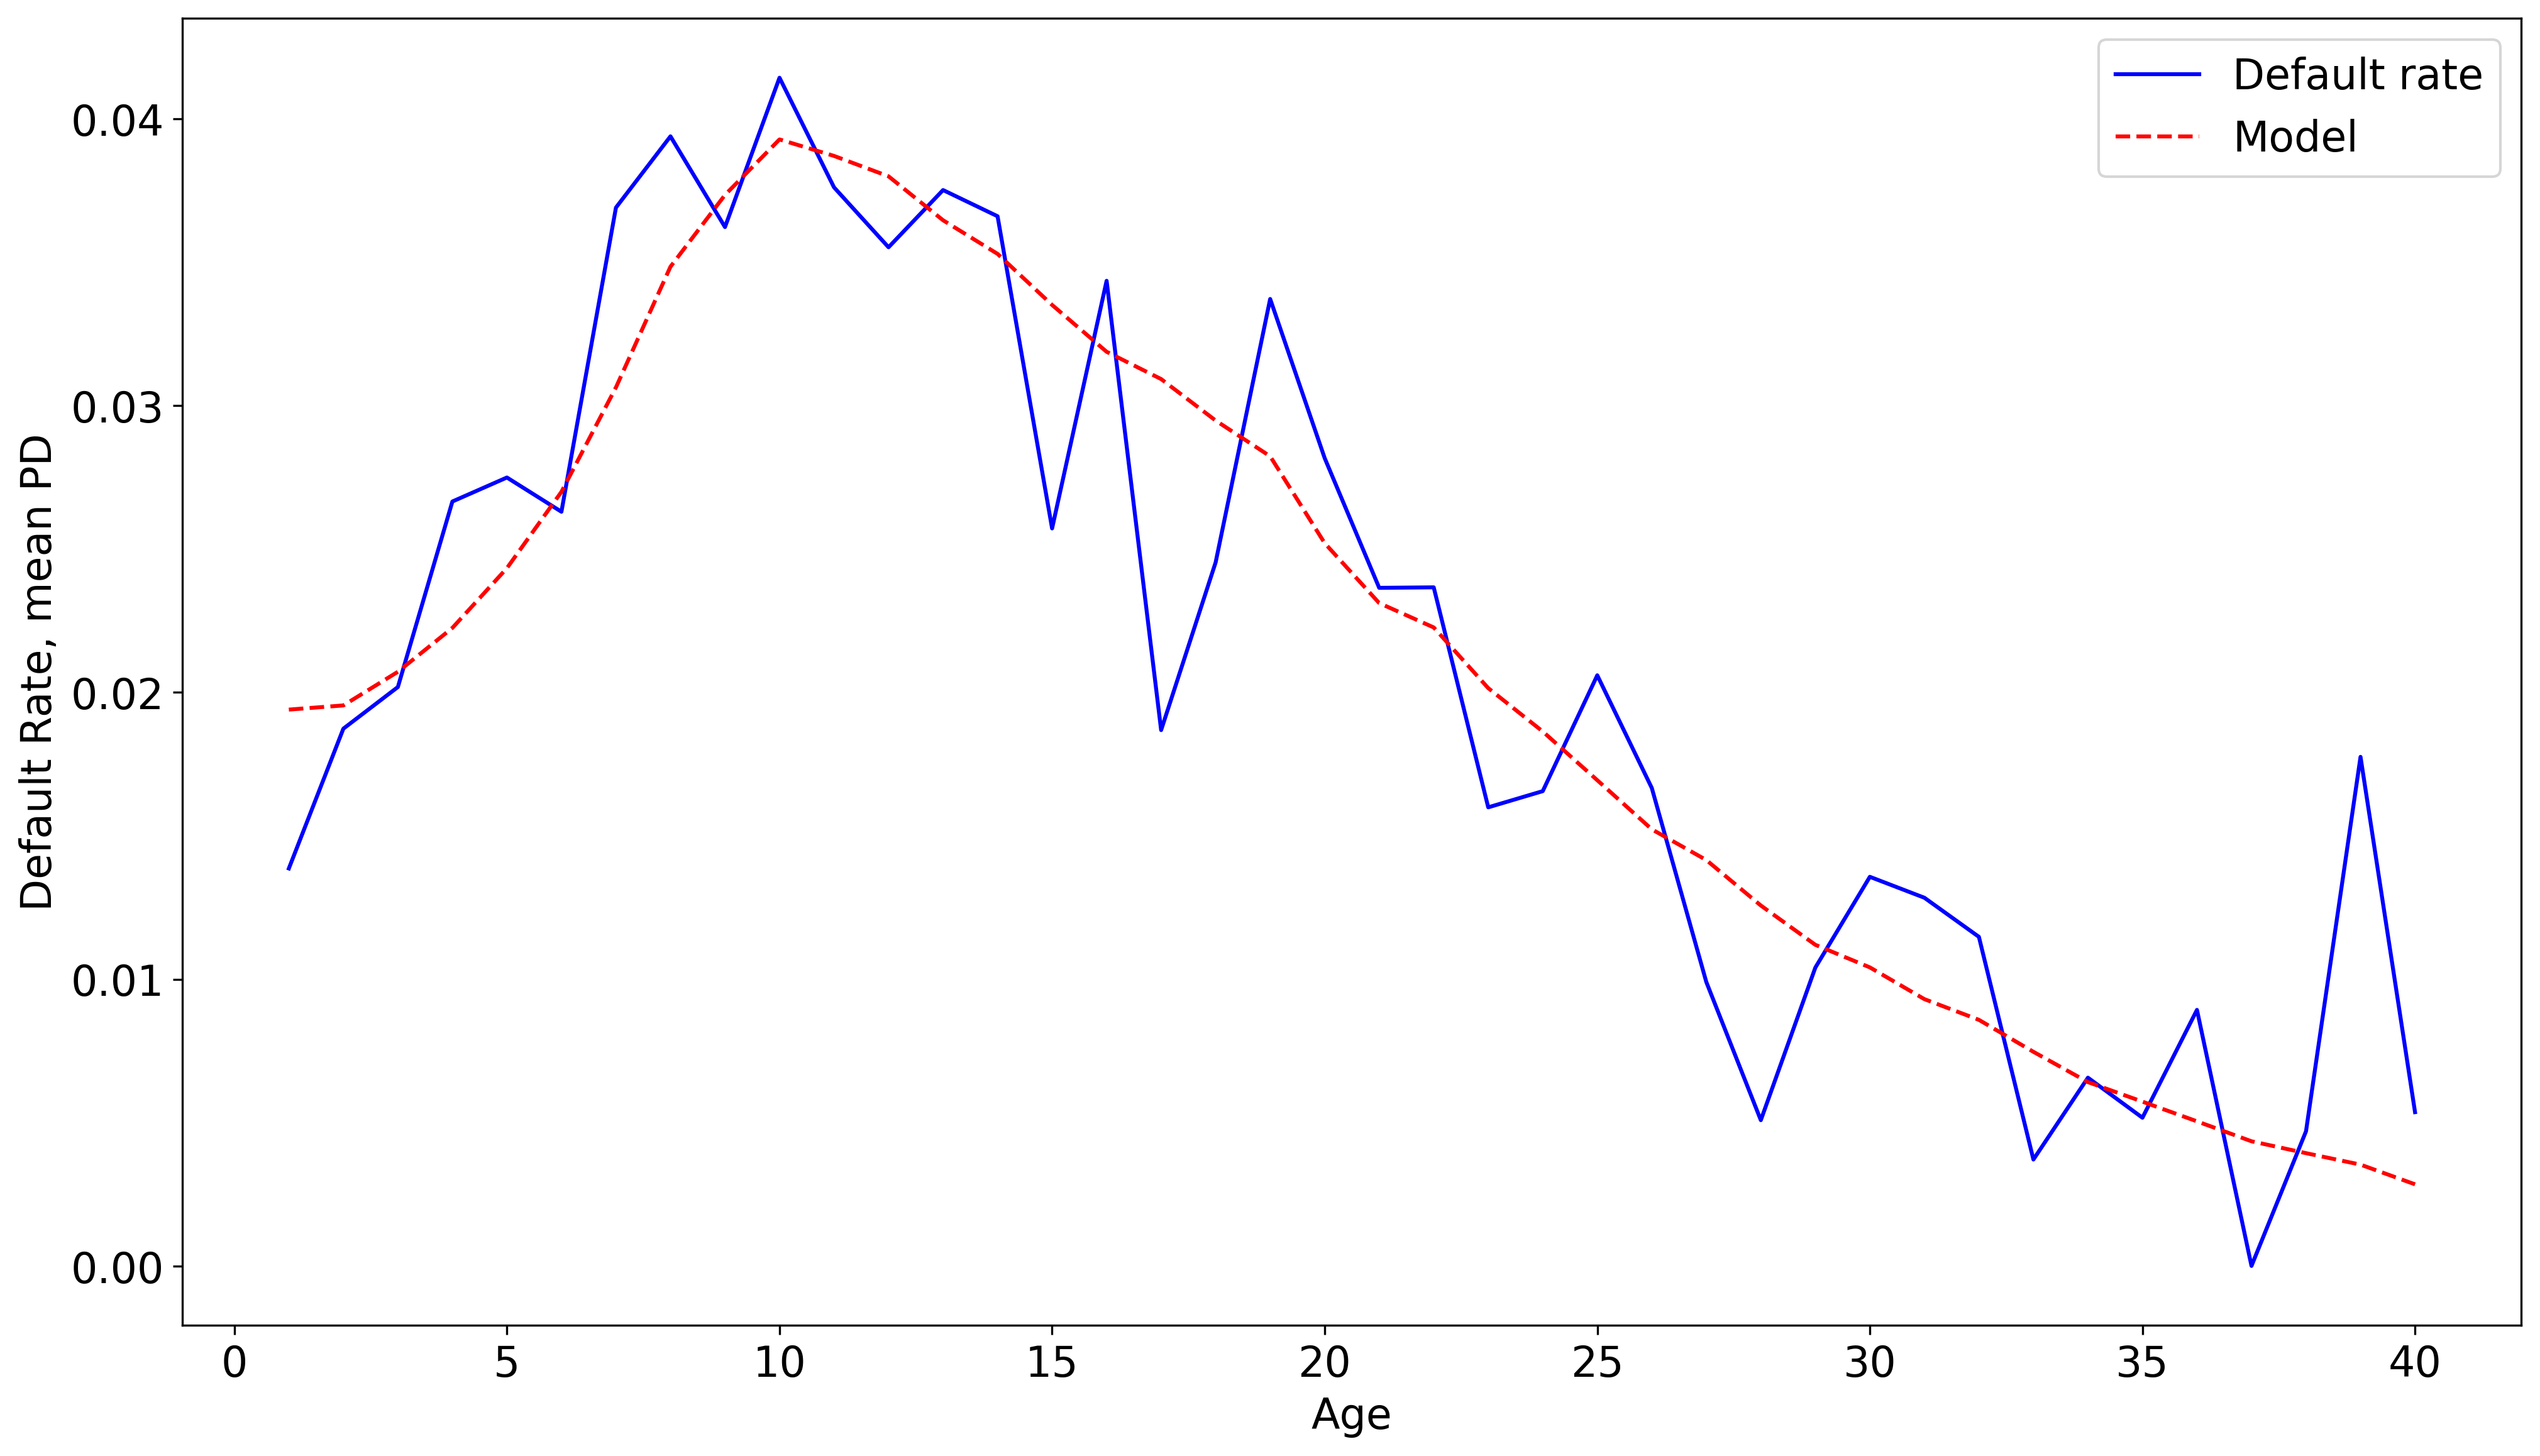

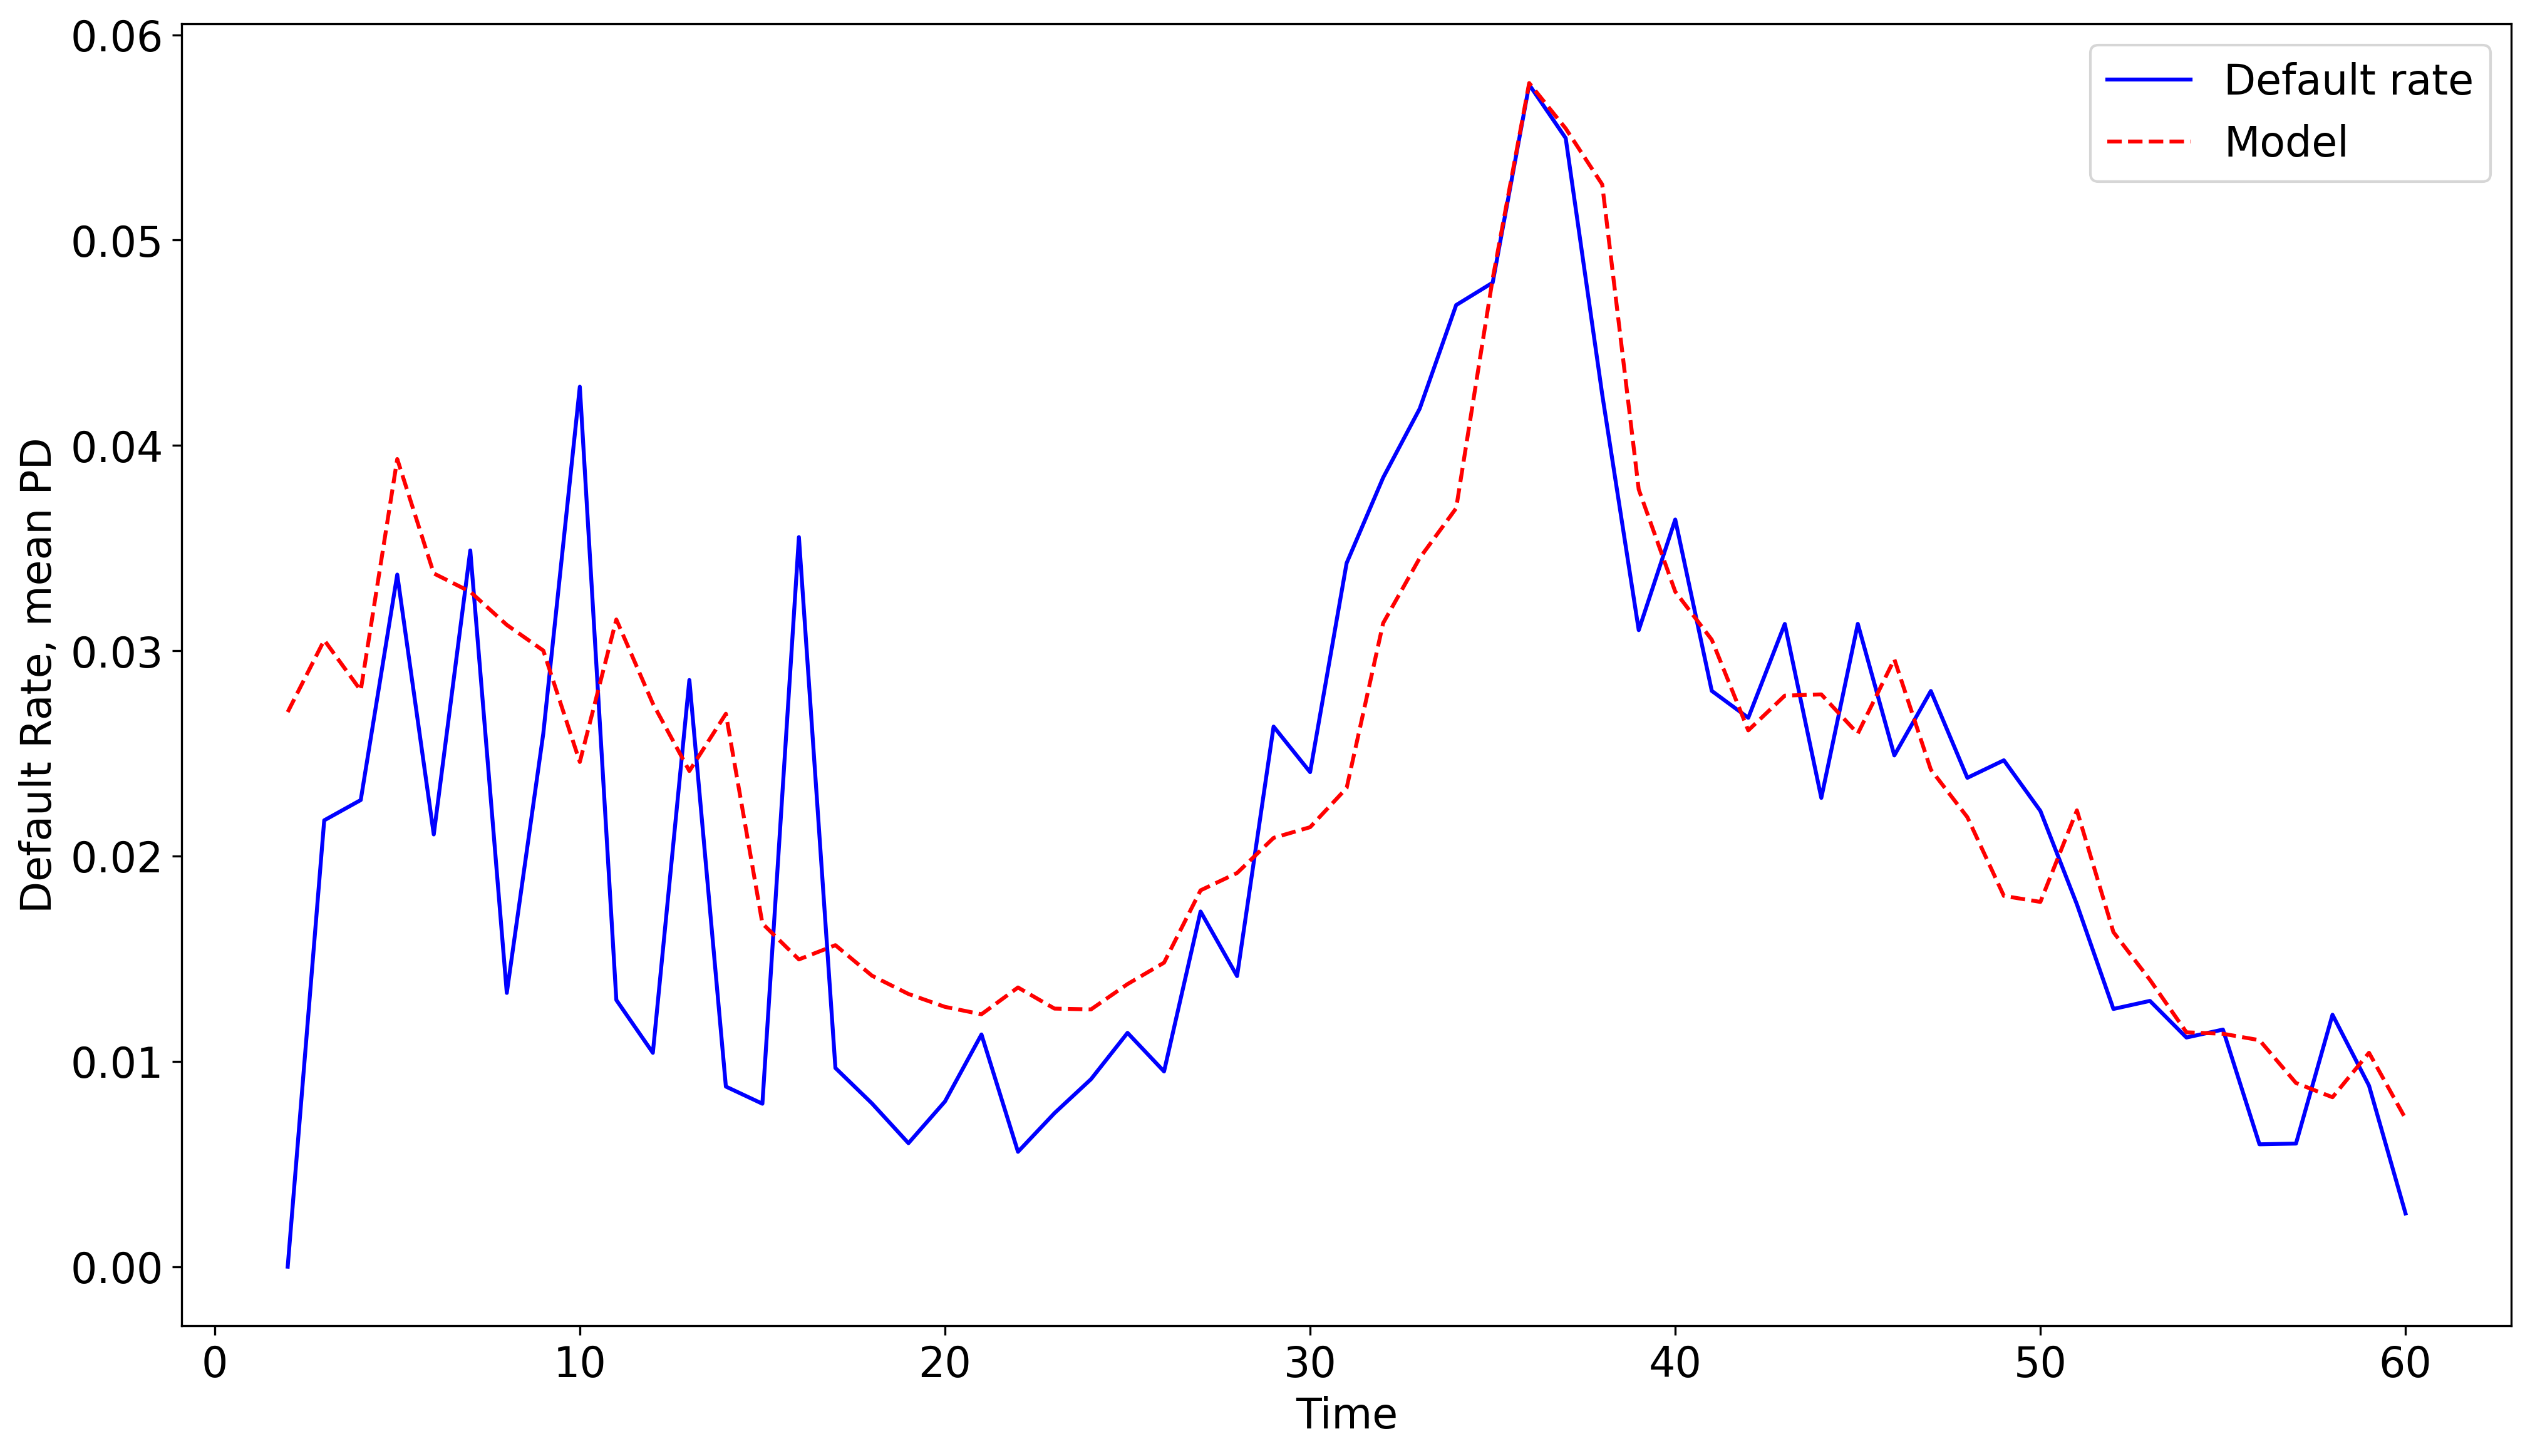

In [9]:
plt.plot('age', 'default_time', data=data2_mean_age, marker='', color='blue', label='Default rate')
plt.plot('age', 'PD_probit_model', data=data2_mean_age, marker='', color='red', label='Model', linestyle='dashed')
plt.xlabel('Age')
plt.ylabel('Default Rate, mean PD')
plt.legend(loc='best')
plt.show()

plt.plot('time', 'default_time', data=data2_mean_time, marker='', color='blue', label='Default rate')
plt.plot('time', 'PD_probit_model', data=data2_mean_time, marker='', color='red', label='Model', linestyle='dashed')
plt.xlabel('Time')
plt.ylabel('Default Rate, mean PD')
plt.legend(loc='best')
plt.show()

In [10]:
macro = data.groupby('time')[['time', 'uer_time', 'gdp_time']].mean()
macro2 = macro[['uer_time', 'gdp_time']]
macro2 = macro2.reset_index(drop=True)

In [11]:
gc_result = grangercausalitytests(macro2, 2)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=76.5928 , p=0.0000  , df_denom=55, df_num=1
ssr based chi2 test:   chi2=80.7706 , p=0.0000  , df=1
likelihood ratio test: chi2=50.5980 , p=0.0000  , df=1
parameter F test:         F=76.5928 , p=0.0000  , df_denom=55, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=14.7527 , p=0.0000  , df_denom=52, df_num=2
ssr based chi2 test:   chi2=32.3424 , p=0.0000  , df=2
likelihood ratio test: chi2=25.6172 , p=0.0000  , df=2
parameter F test:         F=14.7527 , p=0.0000  , df_denom=52, df_num=2


In [12]:
jh_result = coint_johansen(macro2, 0, 1)

print('Johanssen Test, statistic', jh_result.lr1.round(decimals=2))
print('Johanssen Test, threshold', jh_result.cvt.round(decimals=2))

Johanssen Test, statistic [41.16  3.73]
Johanssen Test, threshold [[13.43 15.49 19.93]
 [ 2.71  3.84  6.63]]


In [13]:
adf_result = adfuller(macro2.gdp_time, autolag='AIC')

print('ADF Test for GDP:', adf_result[1].round(decimals=2))

adf_result = adfuller(macro2.uer_time, autolag='AIC')

print('ADF Test for UER:', adf_result[1].round(decimals=2))

ADF Test for GDP: 0.02
ADF Test for UER: 0.59


In [14]:
for i in [1, 2, 3, 4, 5]:
    result = VAR(macro2).fit(i)

    print('Lag Order =', i)
    print('AIC : ', result.aic.round(decimals=2))

Lag Order = 1
AIC :  -3.29
Lag Order = 2
AIC :  -3.44
Lag Order = 3
AIC :  -3.44
Lag Order = 4
AIC :  -3.42
Lag Order = 5
AIC :  -3.33


In [15]:
model_VAR = VAR(macro2).fit(3)
model_VAR.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 25, Aug, 2025
Time:                     09:57:42
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -2.93222
Nobs:                     56.0000    HQIC:                  -3.24225
Log likelihood:          -48.6415    FPE:                  0.0321954
AIC:                     -3.43856    Det(Omega_mle):       0.0254384
--------------------------------------------------------------------
Results for equation uer_time
                 coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------
const               0.541113         0.230403            2.349           0.019
L1.uer_time         0.988293         0.146566            6.743           0.000
L1.gdp_time        -0.169714         0.051577           -3.290   

In [16]:
durbin_watson(model_VAR.resid).round(decimals=2)

array([2.05, 1.98])

In [17]:
macro3 = pd.merge(macro, model_VAR.fittedvalues.add_suffix('_fit'), right_index=True, left_index=True)

print(macro3.round(decimals=2))

      time  uer_time  gdp_time  uer_time_fit  gdp_time_fit
3.0    3.0       3.9      2.85          4.37          1.51
4.0    4.0       4.2      2.27          4.83          0.47
5.0    5.0       4.4      0.93          4.99          0.43
6.0    6.0       4.6      0.49          5.65         -0.03
7.0    7.0       5.3      0.20          5.92          1.99
...    ...       ...       ...           ...           ...
54.0  54.0       7.3      1.51          6.93          2.68
55.0  55.0       7.2      2.42          6.57          1.95
56.0  56.0       6.6      1.72          5.93          2.73
57.0  57.0       6.2      2.56          5.96          2.65
58.0  58.0       6.2      2.87          5.69          2.52

[56 rows x 5 columns]


In [18]:
lags = model_VAR.k_ar

macro4 = macro2.values[-lags:, :]

print(macro4.round(decimals=2))

[[6.2  2.87]
 [5.7  2.44]
 [5.7  2.84]]


In [19]:
macro5 = model_VAR.forecast(y=macro4, steps=160)
macro5 = pd.DataFrame(macro5, columns=macro2.columns + '_forecast')
macro5.index.name = 'time'
macro5.index = macro5.index + 61

macro5 = macro5.reset_index(drop=False)

macro6 = pd.concat([macro3, macro5], sort=True)
macro6 = macro6.reset_index(drop=True)

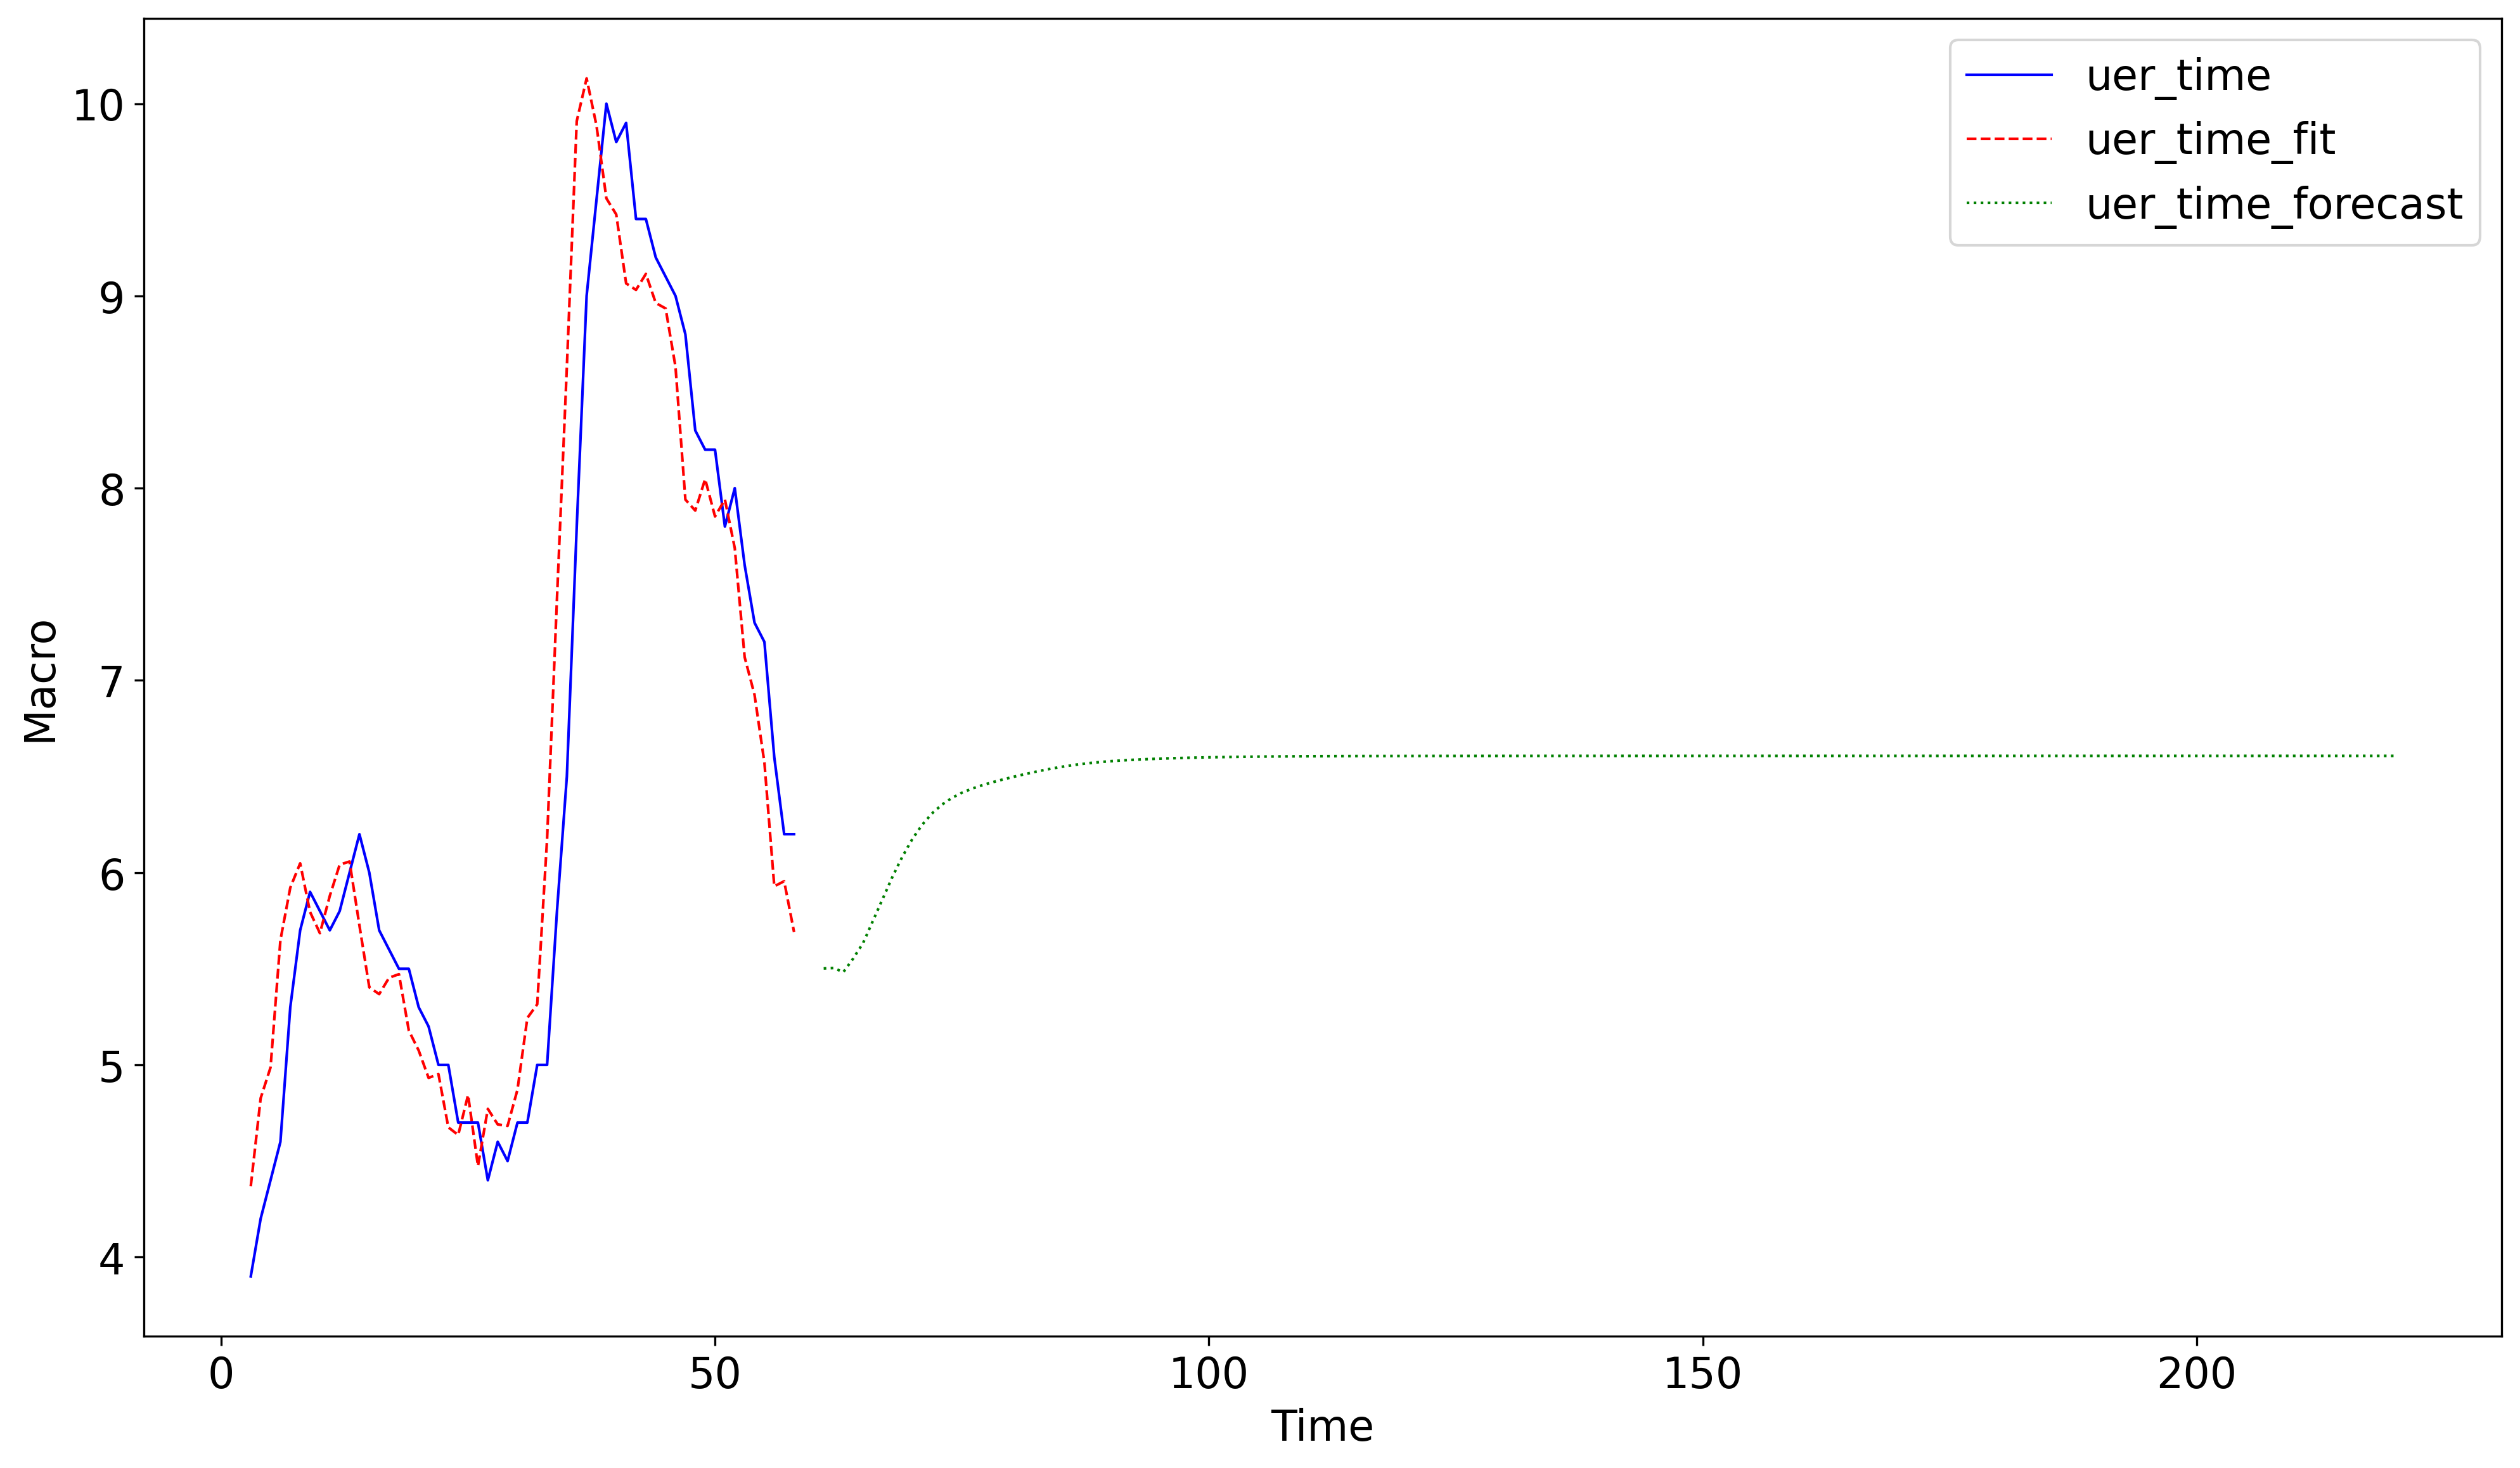

In [20]:
plt.plot('time', 'uer_time', data=macro6, color='blue', linewidth=1)
plt.plot('time', 'uer_time_fit', data=macro6, color='red', linewidth=1, linestyle='dashed')
plt.plot('time', 'uer_time_forecast', data=macro6, color='green', linewidth=1, linestyle='dotted')
plt.xlabel('Time')
plt.ylabel('Macro')
plt.legend(loc='best')
plt.show()

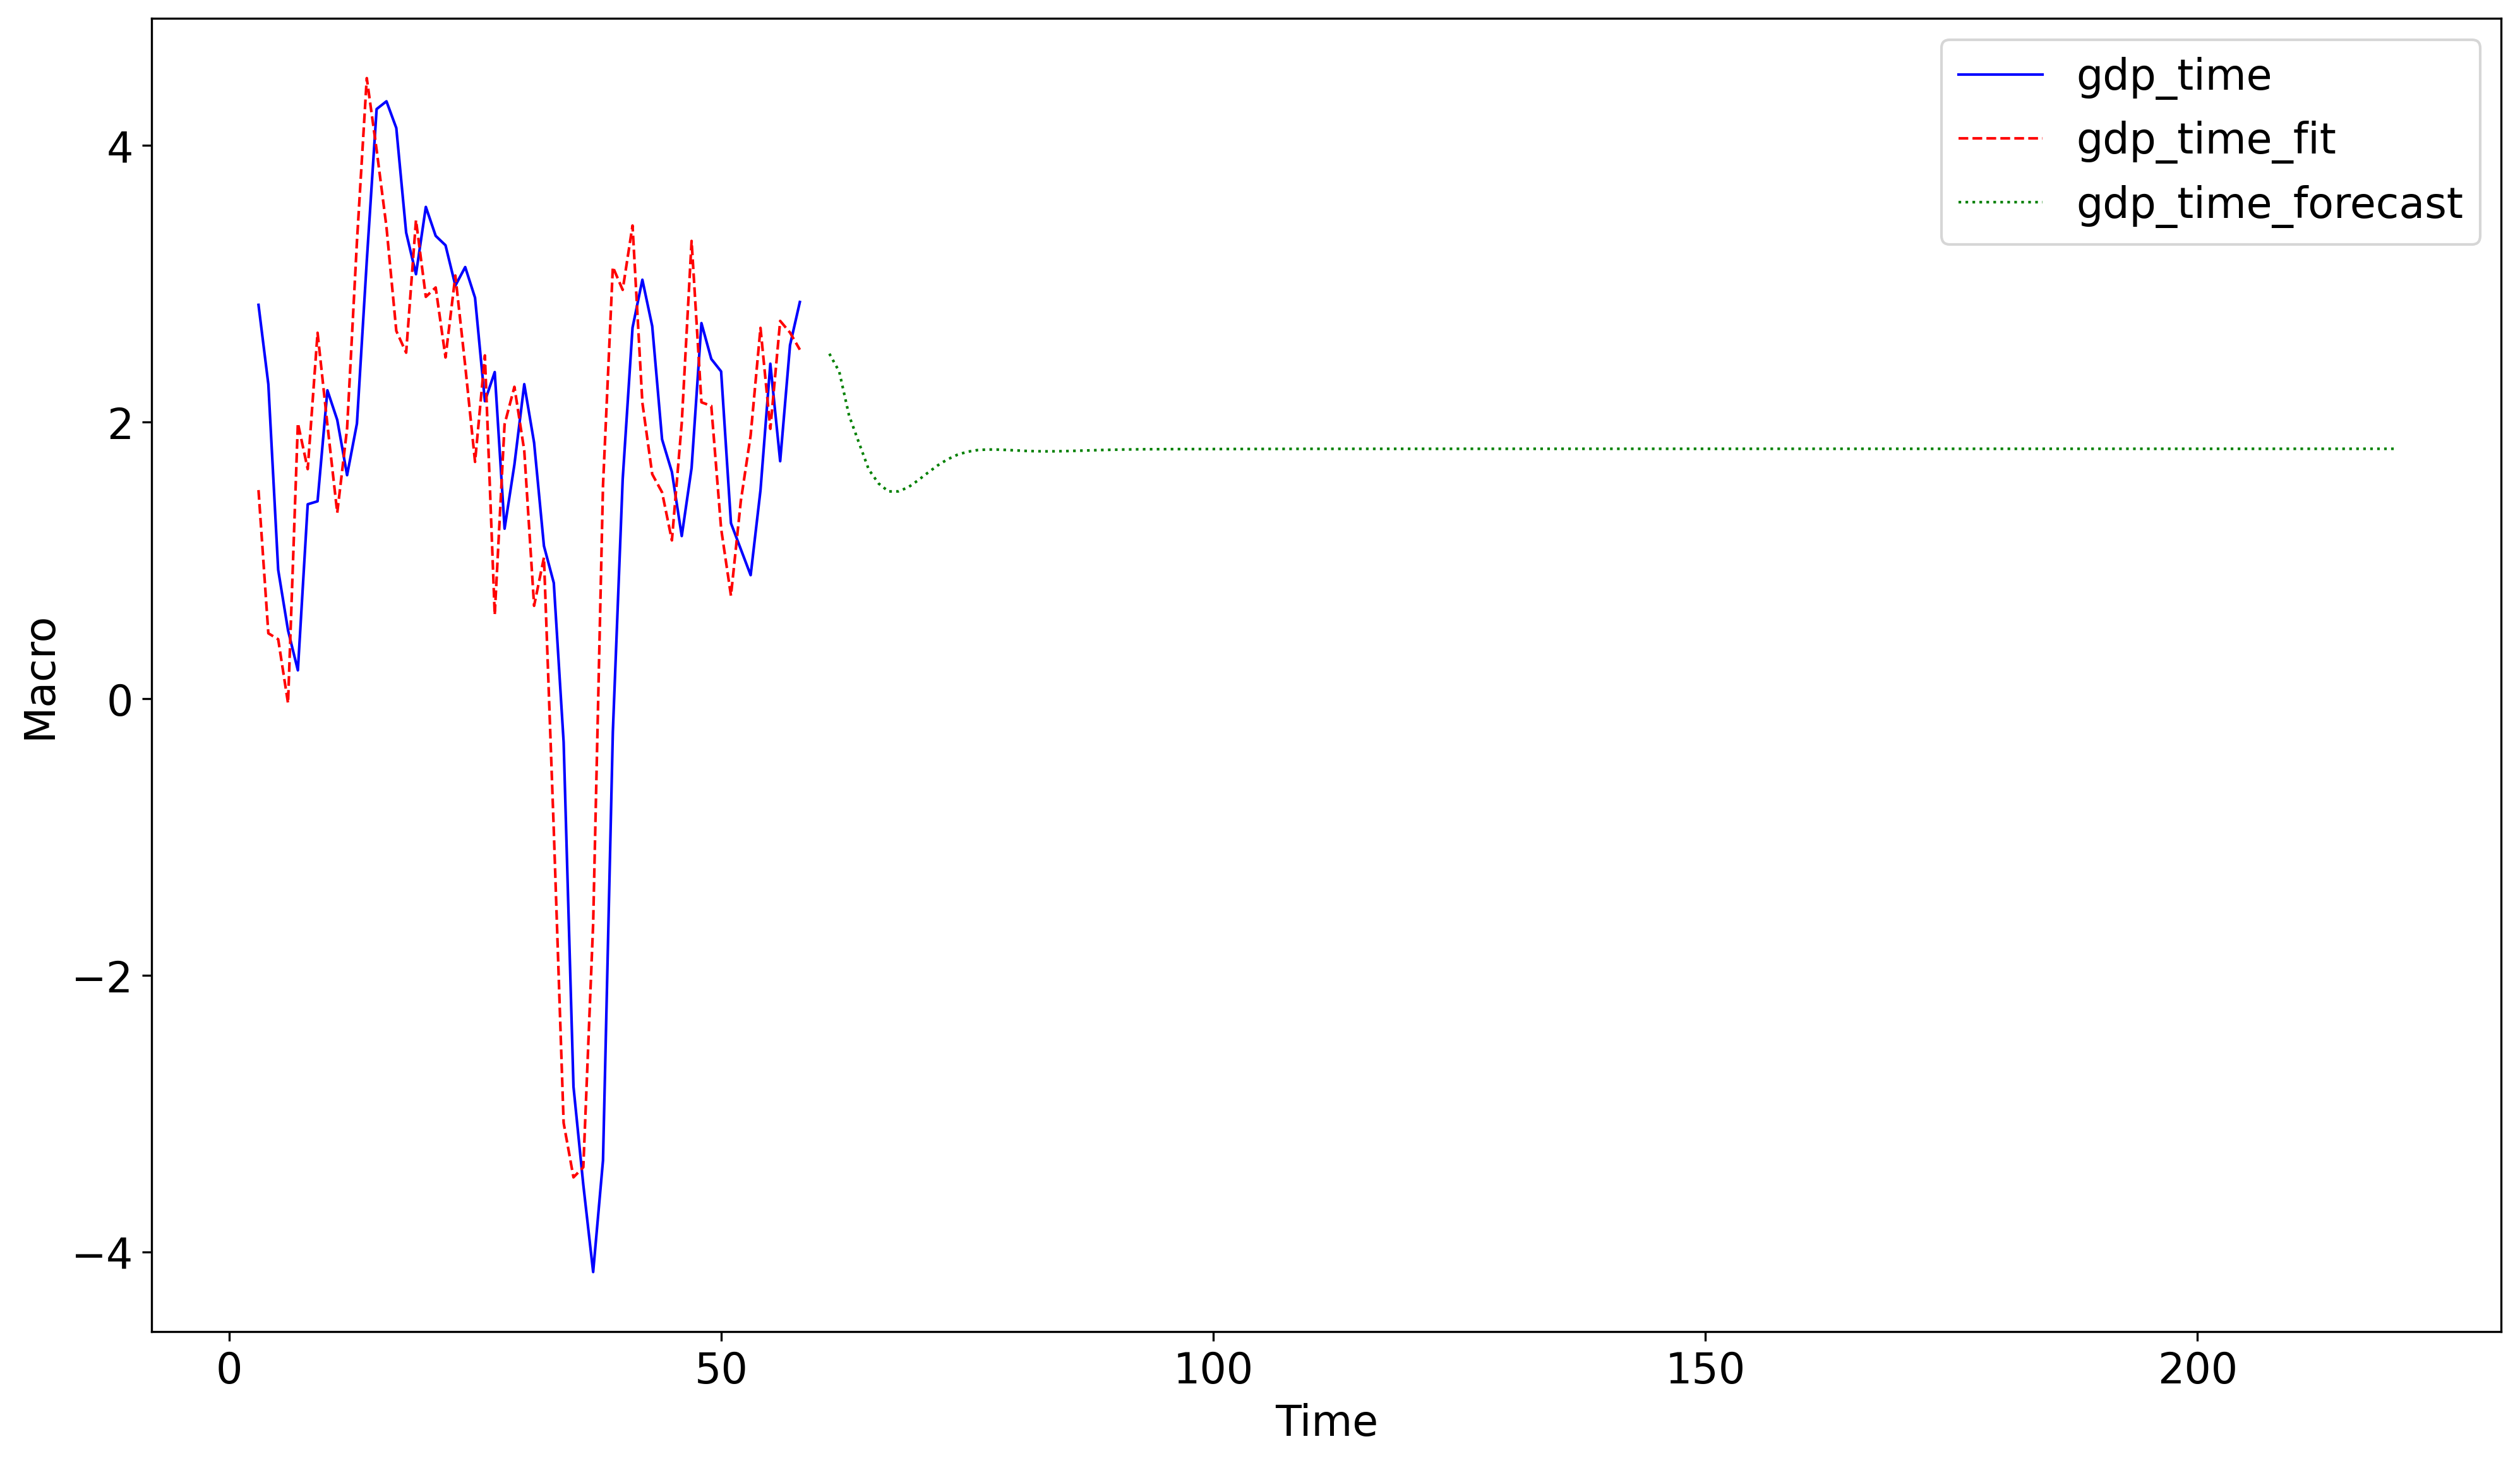

In [21]:
plt.plot('time', 'gdp_time', data=macro6, color='blue', linewidth=1)
plt.plot('time', 'gdp_time_fit', data=macro6, color='red', linewidth=1, linestyle='dashed')
plt.plot('time', 'gdp_time_forecast', data=macro6, color='green', linewidth=1, linestyle='dotted')
plt.xlabel('Time')
plt.ylabel('Macro')
plt.legend(loc='best')
plt.show()

In [23]:
macro7 = macro6[['time', 'uer_time_forecast', 'gdp_time_forecast']]
macro8 = macro7.rename(columns={'uer_time_forecast':'uer_time', 'gdp_time_forecast':'gdp_time'})

In [24]:
data_lifetime = data.query('time == 60').copy()

data_lifetime.loc[:,'TTM'] = data_lifetime.loc[:,'mat_time'].subtract(data_lifetime.loc[:,'time'])
data_lifetime = data_lifetime.reset_index(drop=True)

print('Number of loans in period 61:', len(data_lifetime))

data_lifetime = data_lifetime.loc[np.repeat(data_lifetime.index.values, data_lifetime.TTM)]
data_lifetime = data_lifetime.reset_index(drop=True)

print('Number of observations to lifetime:', len(data_lifetime))

# Take out 20 loans
data_lifetime = data_lifetime.loc[data_lifetime.id.isin([20442, 20444, 20445, 20446, 20447,
    20450, 20451, 20452, 20453, 20454, 20455, 20456, 20457, 20458, 20459, 38839, 43763,
    43765, 43766, 49709])]

# Assign new sequential id
data_lifetime = data_lifetime.sort_values(['id', 'time'], ascending=[1,1])
data_lifetime.id = pd.Categorical(data_lifetime.id)
data_lifetime.loc[:,'id2'] = data_lifetime.id.cat.codes

print('Number of observations to lifetime for 20 loans:', len(data_lifetime))

Number of loans in period 61: 771
Number of observations to lifetime: 63590
Number of observations to lifetime for 20 loans: 2163


In [25]:
data_lifetime.loc[:,'time_tmp'] = data_lifetime.groupby(['id']).cumcount()+1

data_lifetime.loc[:,'age'] = data_lifetime.loc[:,'time']-data_lifetime.loc[:,'orig_time']+data_lifetime.loc[:,'time_tmp']
data_lifetime.loc[:,'age2'] = data_lifetime.loc[:,'age'].multiply(data_lifetime.loc[:,'age'])

data_lifetime.loc[:,'time'] = data_lifetime.loc[:,'time']+data_lifetime.loc[:,'time_tmp']

data_lifetime = data_lifetime.rename(columns={'TTM': 'TTM_0', 'balance_time': 'balance_time_0'})
data_lifetime.loc[:,'TTM'] = data_lifetime.loc[:,'mat_time']-data_lifetime.loc[:,'time']

In [26]:
data_lifetime = data_lifetime.drop(['uer_time','gdp_time'], axis="columns")

data_lifetime = pd.merge(data_lifetime, macro8, on='time')

data_lifetime = data_lifetime.sort_values(['id', 'time'], ascending=[1,1])


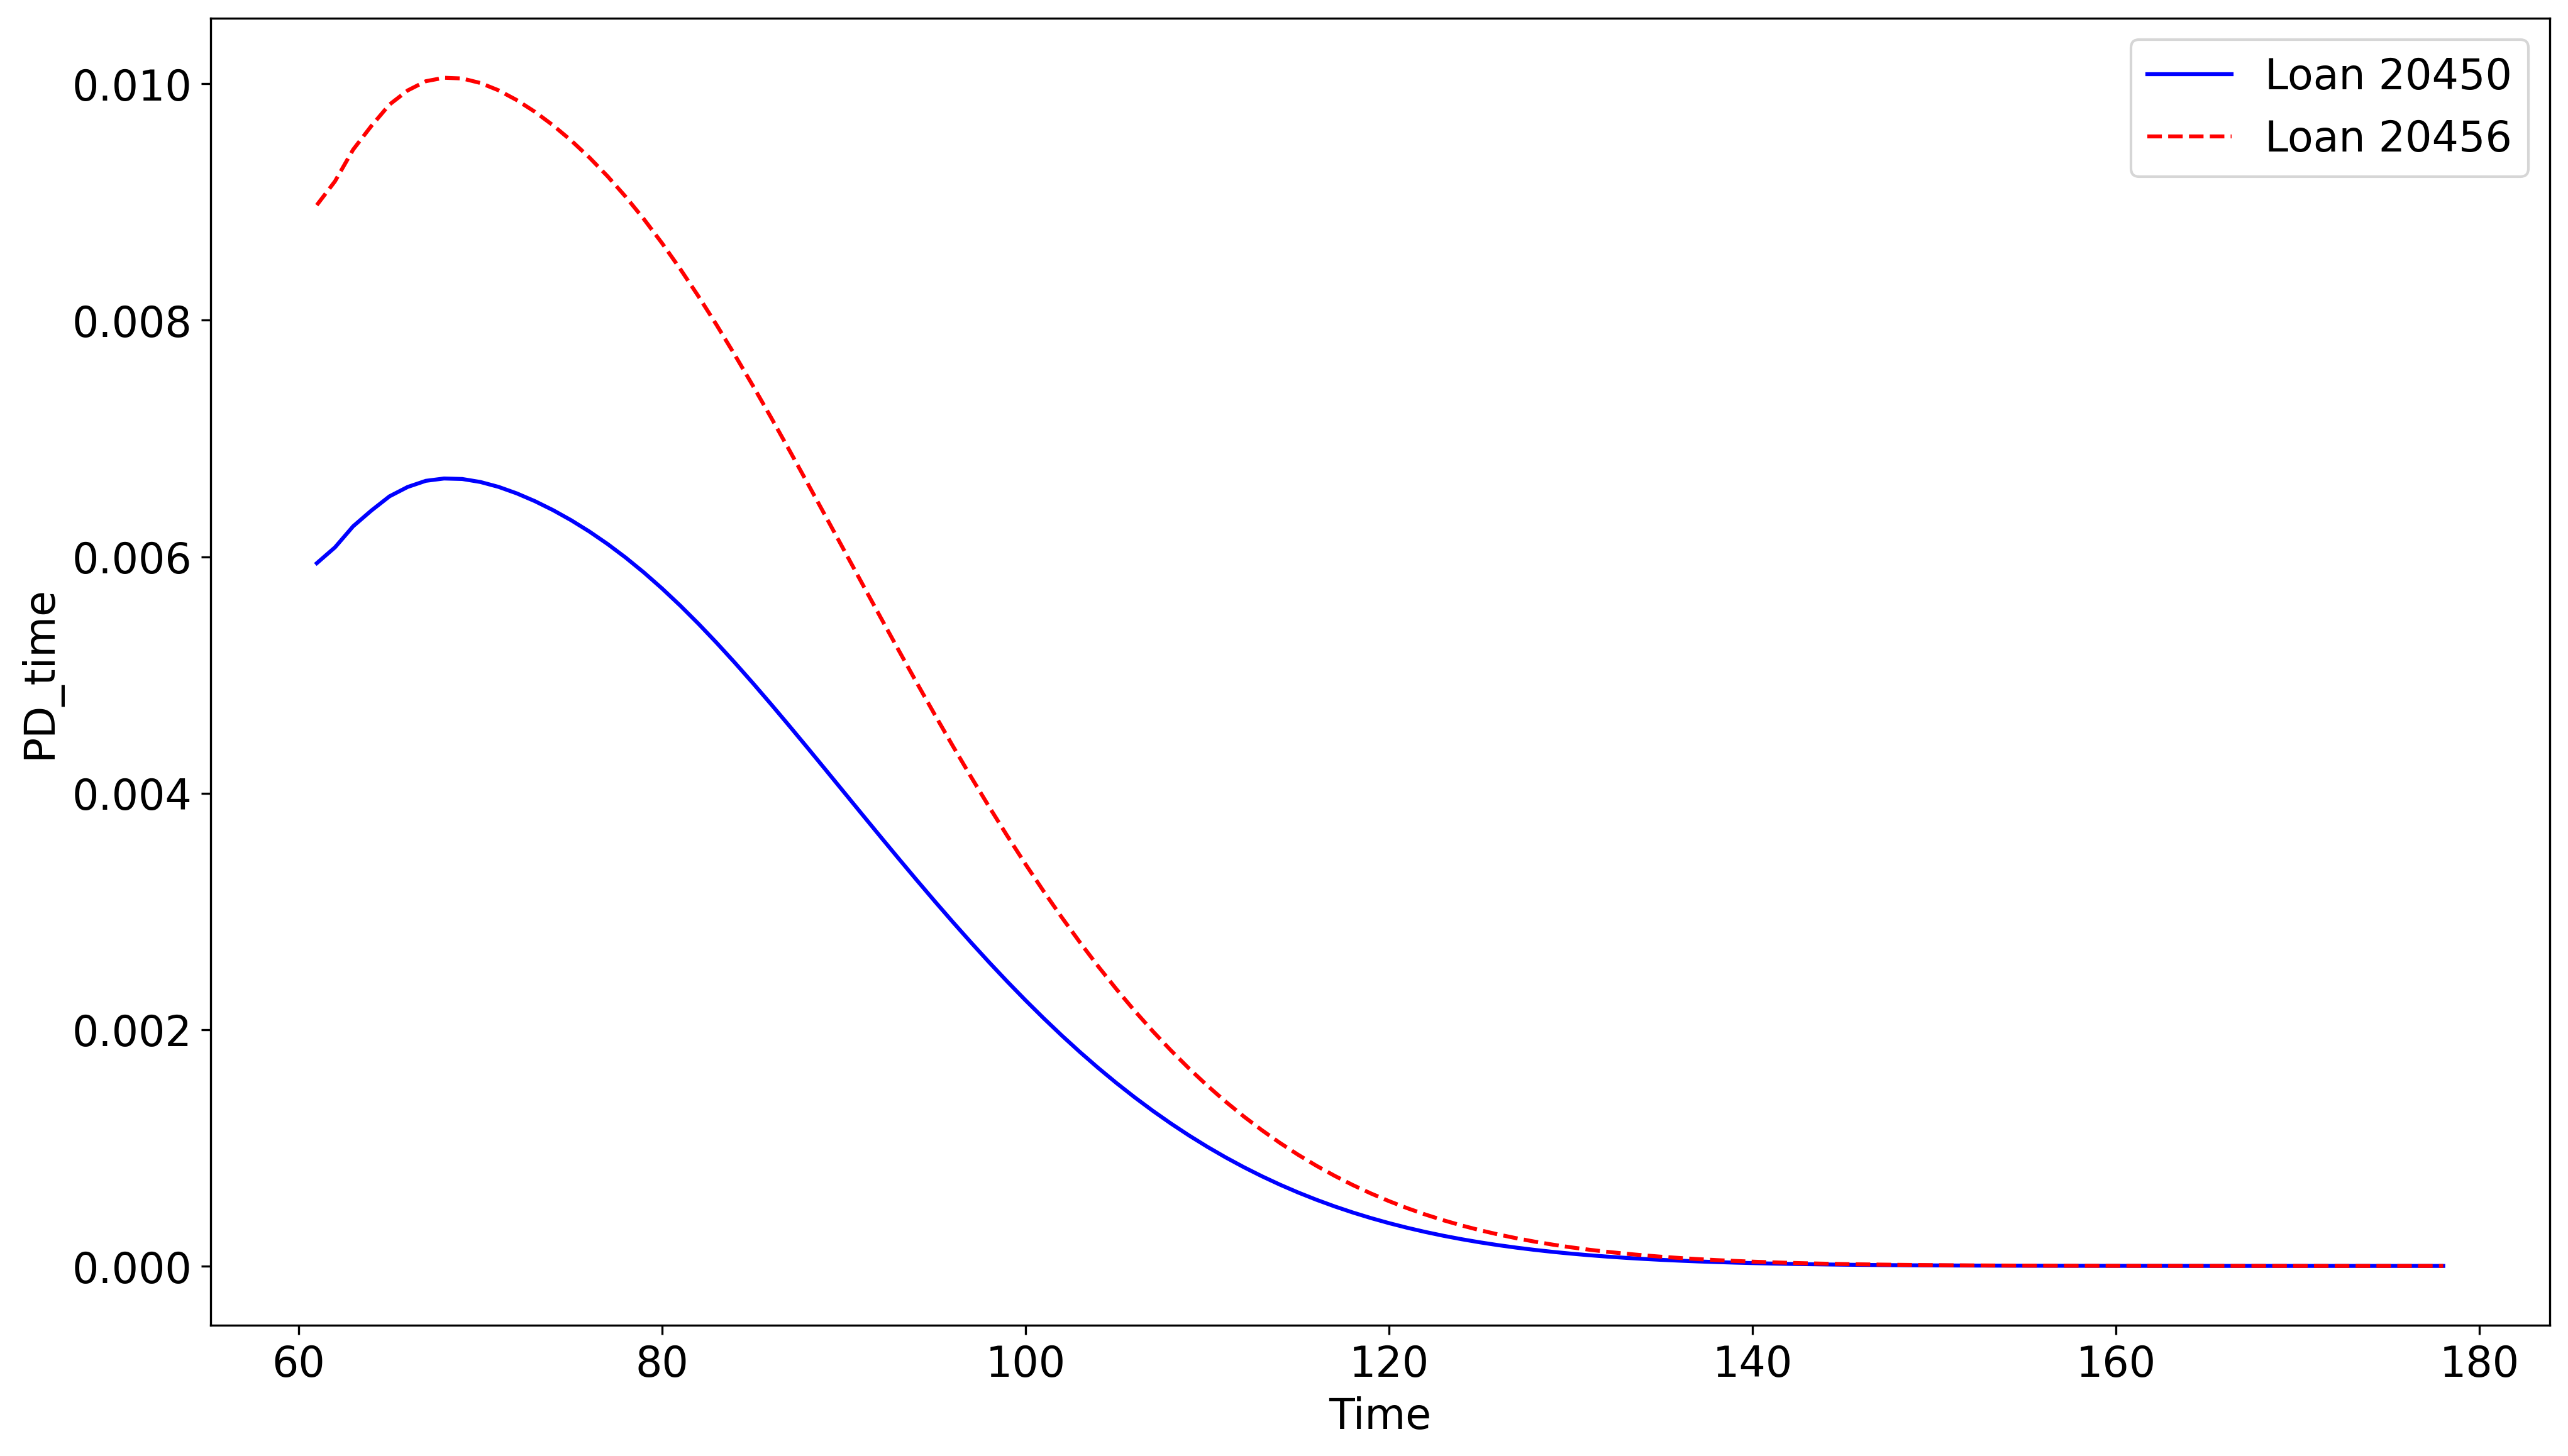

In [27]:
PD_time = pd.DataFrame(model_lr.predict(data_lifetime), columns = ['PD_time'])
data_lifetime = pd.concat([data_lifetime, PD_time], axis=1)

PD_time_20450 = data_lifetime.loc[data_lifetime.id == 20450, :]
PD_time_20456 = data_lifetime.loc[data_lifetime.id == 20456, :]

plt.plot('time', 'PD_time', data=PD_time_20450, marker='', color='blue', label='Loan 20450')
plt.plot('time', 'PD_time', data=PD_time_20456, marker='', color='red', label='Loan 20456', linestyle='dashed')
plt.xlabel('Time')
plt.ylabel('PD_time')
plt.legend(loc='best')
plt.show()

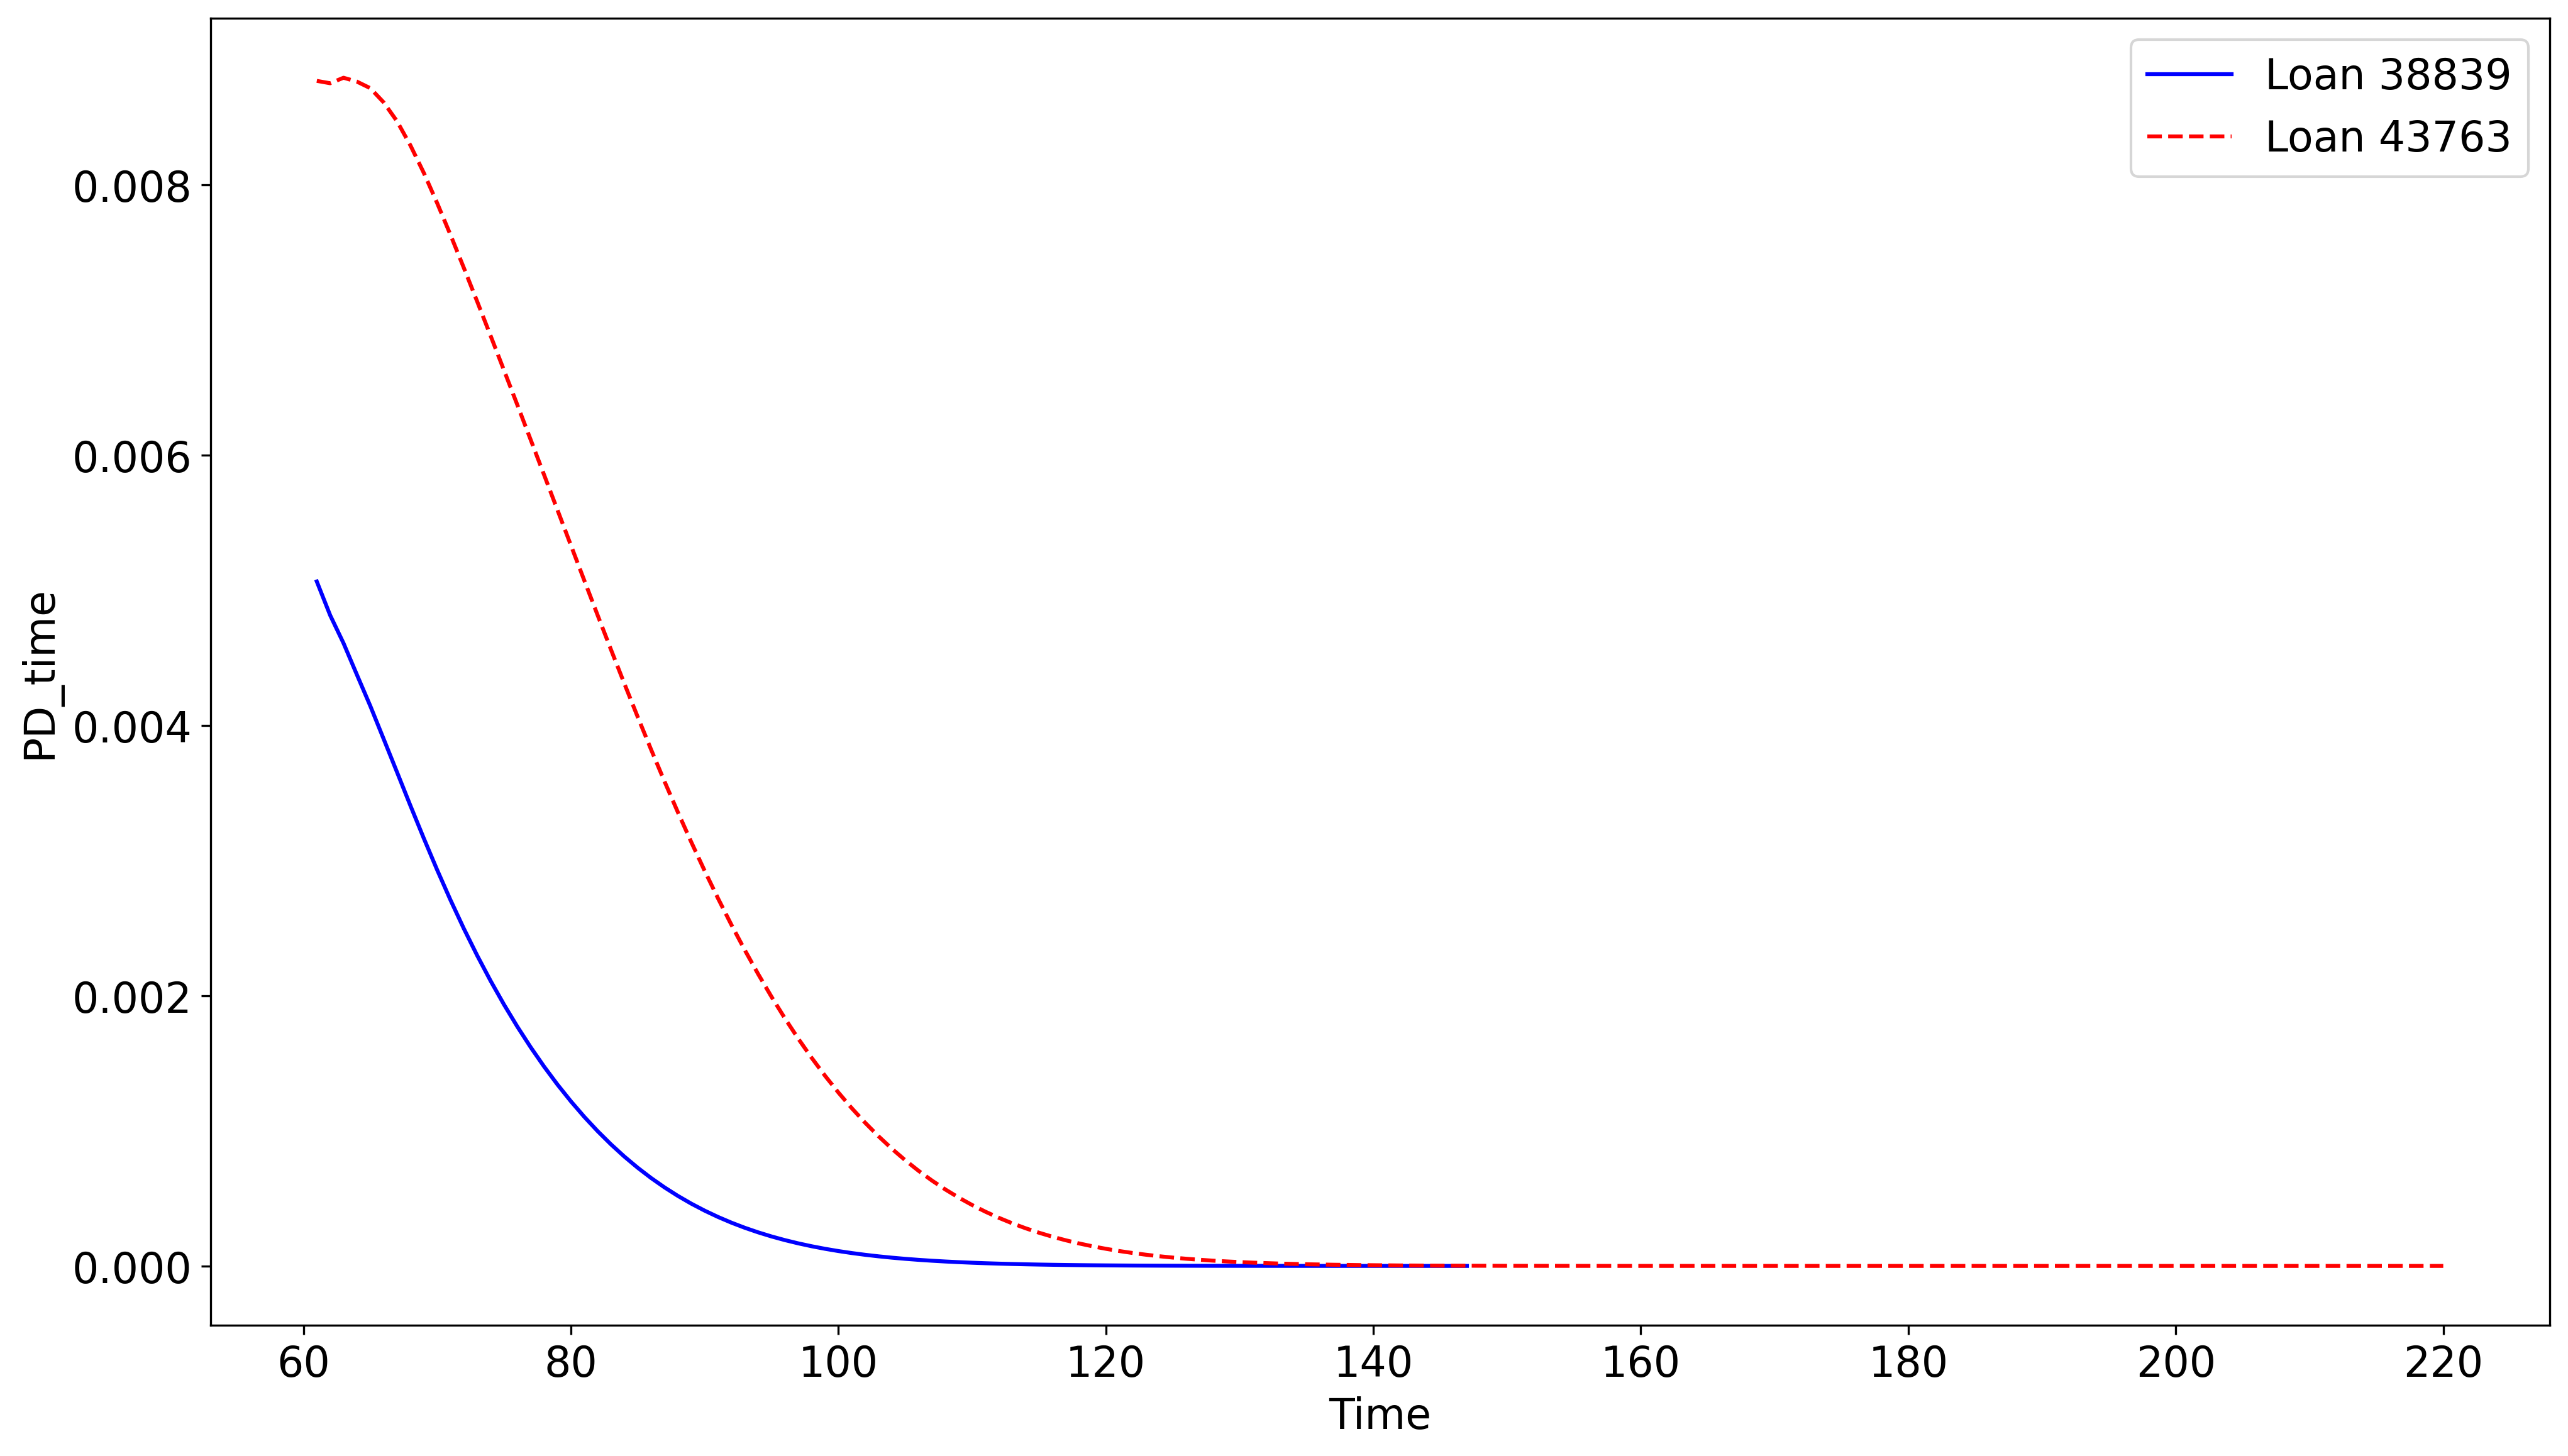

In [29]:
PD_time_38839 = data_lifetime.loc[data_lifetime.id == 38839, :]
PD_time_43763 = data_lifetime.loc[data_lifetime.id == 43763, :]

plt.plot('time', 'PD_time', data=PD_time_38839, marker='', color='blue', label='Loan 38839')
plt.plot('time', 'PD_time', data=PD_time_43763, marker='', color='red', label='Loan 43763', linestyle='dashed')
plt.xlabel('Time')
plt.ylabel('PD_time')
plt.legend(loc='best')
plt.show()

In [30]:
data_lifetime.loc[:,'PP_time'] = data.loc[:,'payoff_time'].mean()
data_lifetime.loc[:,'LGD_time'] = data.loc[:,'lgd_time'].mean()

data_lifetime.loc[:,'annuity'] = ((data_lifetime.loc[:,'interest_rate_time']/(100*4)) * 
    data_lifetime.loc[:,'balance_time_0']) / (1-(1+data_lifetime.loc[:,'interest_rate_time']
    /(100*4))**(-(data_lifetime.loc[:,'TTM_0'])))
data_lifetime.loc[:,'EAD_time'] = data_lifetime.loc[:,'balance_time_0'] * (1+data_lifetime.loc[:,'interest_rate_time']/(100*4))**(data_lifetime.loc[:,'TTM_0'] - data_lifetime.loc[:,'TTM']) - data_lifetime.loc[:,'annuity'] * ((1+data_lifetime.loc[:,'interest_rate_time']/(100*4))**(data_lifetime.loc[:,'TTM_0'] - data_lifetime.loc[:,'TTM'])-1) / (data_lifetime.loc[:,'interest_rate_time']/(100*4))

In [31]:
data_lifetime2 = data_lifetime.loc[:, ['id2', 'time', 'PD_time', 'PP_time']]
data_lifetime2['SP_time'] = 1
data_lifetime2['SP_time_tmp'] = 1

results = pd.DataFrame(columns=data_lifetime2.columns.values)

In [32]:
for k in range(0,20,1):
    tmp = data_lifetime2.loc[data_lifetime2.id2 == k, :].copy()
    tmp = tmp.reset_index(drop=True)

    for j in range(0,len(tmp),1):

        for i in range(0,j,1):
            tmp.iloc[j, 5] = 1-tmp.iloc[j-i,2]-tmp.iloc[j-i,3]
            tmp.iloc[j, 4] = tmp.iloc[j,4] * tmp.iloc[j,5]
    results = pd.concat([results, tmp], sort=False)

results = results.drop(['PD_time', 'PP_time', 'SP_time_tmp'], axis=1)
data_lifetime = pd.merge(data_lifetime, results, on=['id2','time'])

In [33]:
data_lifetime2 = data_lifetime.loc[data_lifetime['time'] <= 64, :].copy()

data_lifetime2.loc[:,'EL'] = data_lifetime2.loc[:,'PD_time'] * data_lifetime2.loc[:,'SP_time'] \
    * data_lifetime2.loc[:,'LGD_time'] * data_lifetime2.loc[:,'EAD_time']

EL = data_lifetime2.loc[:,'EL'].sum()

print(round(EL, 2))

153024.45


In [34]:
data_lifetime.loc[:,'PVEL'] = data_lifetime.loc[:,'PD_time']*data_lifetime.loc[:,'SP_time'] \
    *data_lifetime.loc[:,'LGD_time']*data_lifetime.loc[:,'EAD_time']/(1+data_lifetime.loc[:,'interest_rate_time']/(100*4))**(data_lifetime.loc[:,'time']-60)

CECL = data_lifetime.loc[:,'PVEL'].sum()

print(round(CECL, 2))

558965.42


In [35]:
listid = data_lifetime.id.unique()
data_inital = data[data['id'].isin(listid)]
data_inital = data_inital.loc[data_inital.time == data_inital.first_time, :].sort_values(['id']).reset_index(drop=True)

data_61 = data_lifetime.query('time == 61').copy().sort_values(['id']).reset_index(drop=True)

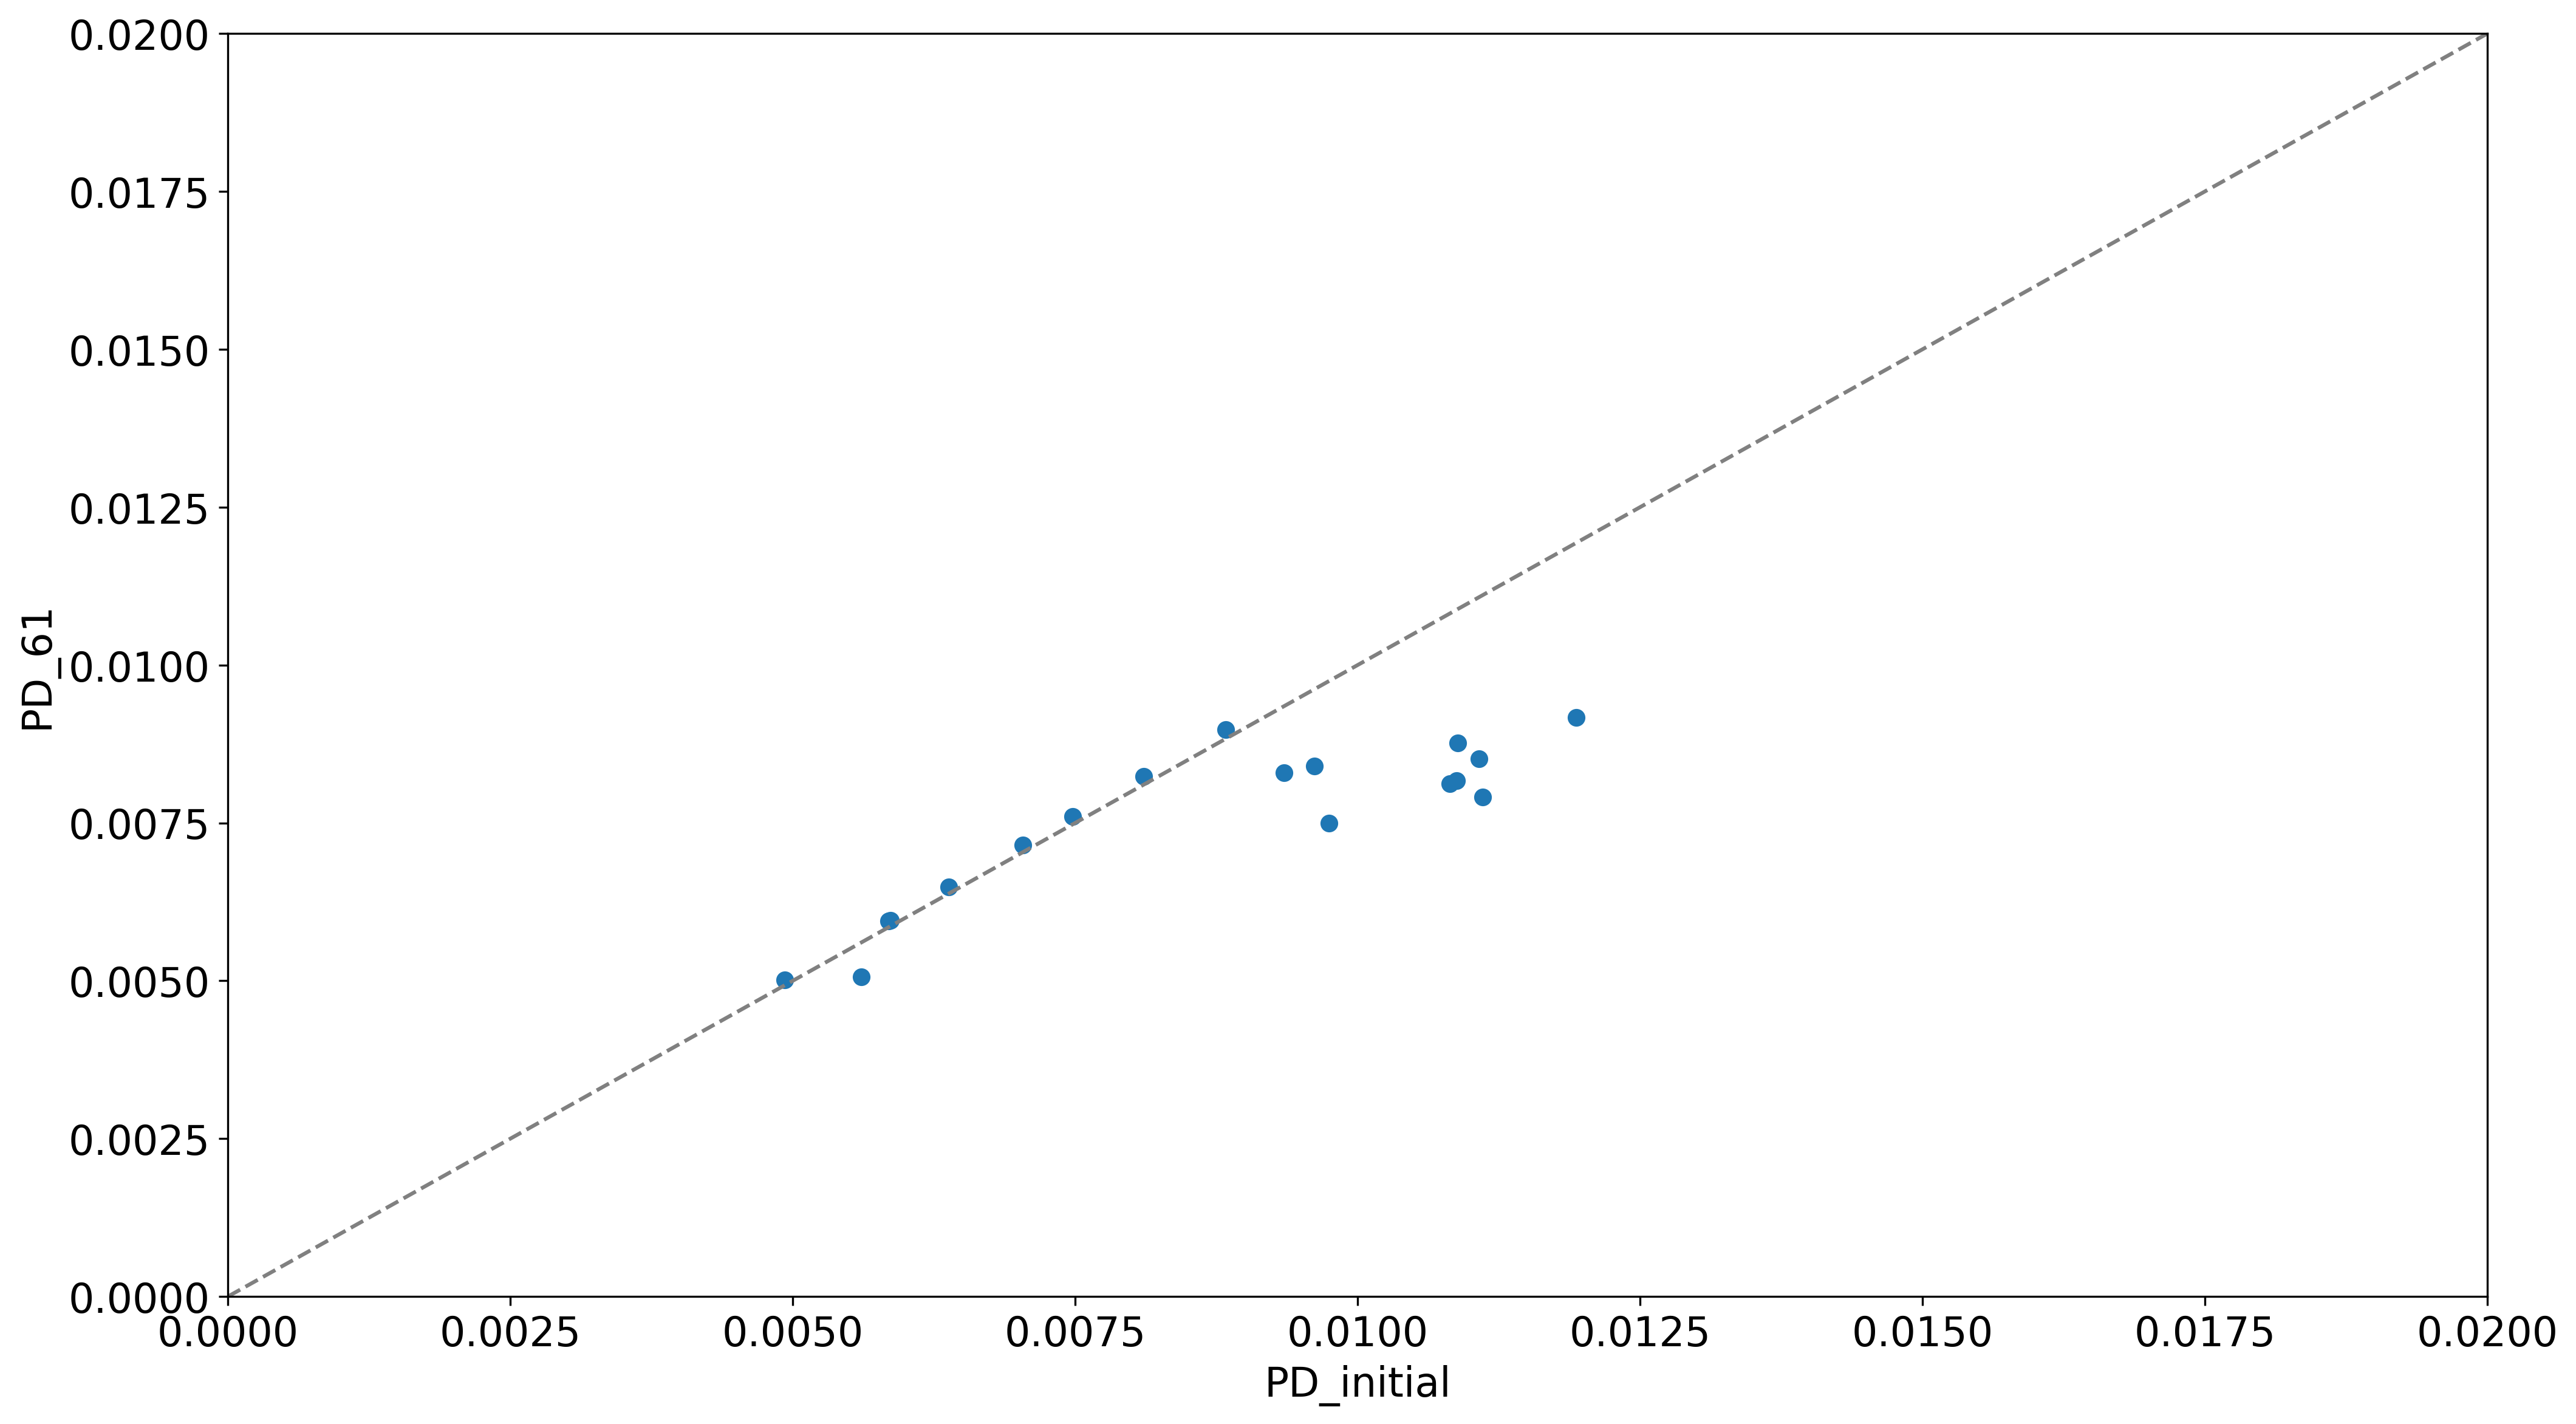

In [36]:
PD_initial = pd.DataFrame(model_lr.predict(data_inital), columns = ['PD_initial'])

PD_61 = pd.DataFrame(model_lr.predict(data_61), columns = ['PD_61'])

SICR = PD_initial.merge(PD_61, left_index=True, right_index=True)

SICR['ratio'] = (SICR.PD_61/SICR.PD_initial)-1

plt.scatter('PD_initial', 'PD_61', data=SICR)
plt.ylabel('PD_61')
plt.xlabel('PD_initial')
plt.plot([0,0.02], [0,0.02], color='gray', linestyle='dashed')
plt.xlim((0,0.02))
plt.ylim((0,0.02))
plt.show()

In [37]:
print(SICR.sort_values(by=['ratio'], ascending=False).round(decimals=3))

    PD_initial  PD_61  ratio
9        0.005  0.005  0.016
5        0.006  0.006  0.016
8        0.006  0.006  0.016
11       0.006  0.006  0.016
13       0.007  0.007  0.016
..         ...    ...    ...
2        0.012  0.009 -0.232
0        0.011  0.008 -0.249
4        0.011  0.008 -0.249
17       0.011  0.008 -0.288
18       0.022  0.006 -0.745

[19 rows x 3 columns]


In [38]:
data_lifetime.loc[:,'PD_time'] = data['default_time'].mean()
data_lifetime.loc[:,'PP_time'] = data['payoff_time'].mean()
data_lifetime.loc[:,'LGD_time'] = data['lgd_time'].mean()

data_lifetime.loc[:,'one'] = 0
data_lifetime.loc[:,'two'] = 0
data_lifetime.loc[:,'three'] = 0
data_lifetime.loc[:,'four'] = 0
data_lifetime.loc[:,'five'] = 0

In [39]:
data_lifetime.loc[:,'PD4'] = data_lifetime.loc[:,'PD_time']

data_lifetime = data_lifetime.sort_values(by=['id', 'time'])

data_lifetime.loc[:,'PD3'] = data_lifetime.groupby(['id'])['PD4'].shift(1)
data_lifetime.loc[:,'PD2'] = data_lifetime.groupby(['id'])['PD4'].shift(2)
data_lifetime.loc[:,'PD1'] = data_lifetime.groupby(['id'])['PD4'].shift(3)

data_lifetime.loc[:,'PD_annual'] = data_lifetime.loc[:,'PD1']+(1-data_lifetime.loc[:,'PD1'])*data_lifetime.loc[:,'PD2']+(1-data_lifetime.loc[:,'PD1'])*(1-data_lifetime.loc[:,'PD2'])*data_lifetime.loc[:,'PD3']+(1-data_lifetime.loc[:,'PD1'])*(1-data_lifetime.loc[:,'PD2'])*(1-data_lifetime.loc[:,'PD3'])*data_lifetime.loc[:,'PD4']

data_lifetime.loc[:,'DLGD'] = 0.2+0.8*data_lifetime.loc[:,'LGD_time']
data_lifetime.loc[:,'WCDR'] = norm.cdf((norm.ppf(data_lifetime.loc[:,'PD_annual'])+sqrt(0.15)*norm.ppf(0.999))/sqrt(1-0.15))

data_lifetime.loc[:,'equity'] = data_lifetime.loc[:,'WCDR']*data_lifetime.loc[:,'DLGD']-data_lifetime.loc[:,'PD_time']*data_lifetime.loc[:,'LGD_time']
data_lifetime.loc[:,'debt'] = 1-data_lifetime.loc[:,'equity']

data_lifetime.loc[:,'CC'] = data_lifetime.loc[:,'equity']*(data_lifetime.loc[:,'rate_time']/ (4*100)+0.06/4)+data_lifetime.loc[:,'debt']*(data_lifetime.loc[:,'rate_time']/(4*100)+0.02/4)

In [40]:
results = pd.DataFrame(columns=['id2', 'loan_rate', 'interest_rate_time'])

for k in range(0,20,1):
    data_lifetime2 = data_lifetime.loc[data_lifetime.id2 == k, :].copy()

    data_lifetime2.loc[data_lifetime2.time == 61, 'one'] = -data_lifetime2.loc[:, 'balance_time_0']

    data_lifetime2.loc[:, 'two'] = data_lifetime2.loc[:, 'SP_time']*(1-data_lifetime2.loc[:, 'PD_time'])-data_lifetime2.loc[:, 'PP_time']*data_lifetime2.loc[:, 'EAD_time']/(1+data_lifetime2.loc[:, 'CC']/(100*4))**(data_lifetime2.loc[:, 'time']-60)

    data_lifetime2.loc[:, 'three'] = data_lifetime2.loc[:, 'PP_time']*data_lifetime2.loc[:, 'SP_time']*(1-data_lifetime2.loc[:, 'PD_time']-data_lifetime2.loc[:, 'PP_time'])*data_lifetime2.loc[:, 'EAD_time']/(1+data_lifetime2.loc[:, 'CC']/(100*4))**(data_lifetime2.loc[:, 'time']-60)

    data_lifetime2.loc[:, 'four'] = data_lifetime2.loc[:, 'PD_time']*data_lifetime2.loc[:, 'SP_time']*(1-data_lifetime2.loc[:, 'LGD_time'])*data_lifetime2.loc[:, 'EAD_time']/(1+data_lifetime2.loc[:, 'CC']/(100*4))**(data_lifetime2.loc[:, 'time']-60)

    data_lifetime2.loc[data_lifetime2['time'] == data_lifetime2.loc[:, 'mat_time'], 'five'] = data_lifetime2.loc[:, 'SP_time']*(1-data_lifetime2.loc[:, 'PD_time'])*data_lifetime2.loc[:, 'balance_time_0']/(1+data_lifetime2.loc[:, 'CC']/(100*4))**(data_lifetime2.loc[:, 'time']-60)

    data_lifetime2_sum = data_lifetime2[['one', 'two', 'three', 'four', 'five']].sum()

    data_lifetime2_sum['loan_rate'] = (4*100)*(-data_lifetime2_sum['one'] - data_lifetime2_sum['three'] - data_lifetime2_sum['four'] - data_lifetime2_sum['five']) / (data_lifetime2_sum['two'])

    data_lifetime2_sum['interest_rate_time'] = data_lifetime2['interest_rate_time'].mean()
    data_lifetime2_sum['id'] = k

    tmp = pd.DataFrame(np.array([[data_lifetime2_sum.id, data_lifetime2_sum.loan_rate,
                                  data_lifetime2_sum.interest_rate_time]]), columns=['id2', 'loan_rate',
                                                                                   'interest_rate_time'])

    results = pd.concat([results, tmp])


       interest_rate_time  loan_rate
count               19.00      19.00
mean                 4.04     -31.50
std                  0.83      11.23
min                  2.00     -56.99
25%                  4.12     -29.70
50%                  4.25     -28.54
75%                  4.50     -26.48
max                  4.88     -11.83


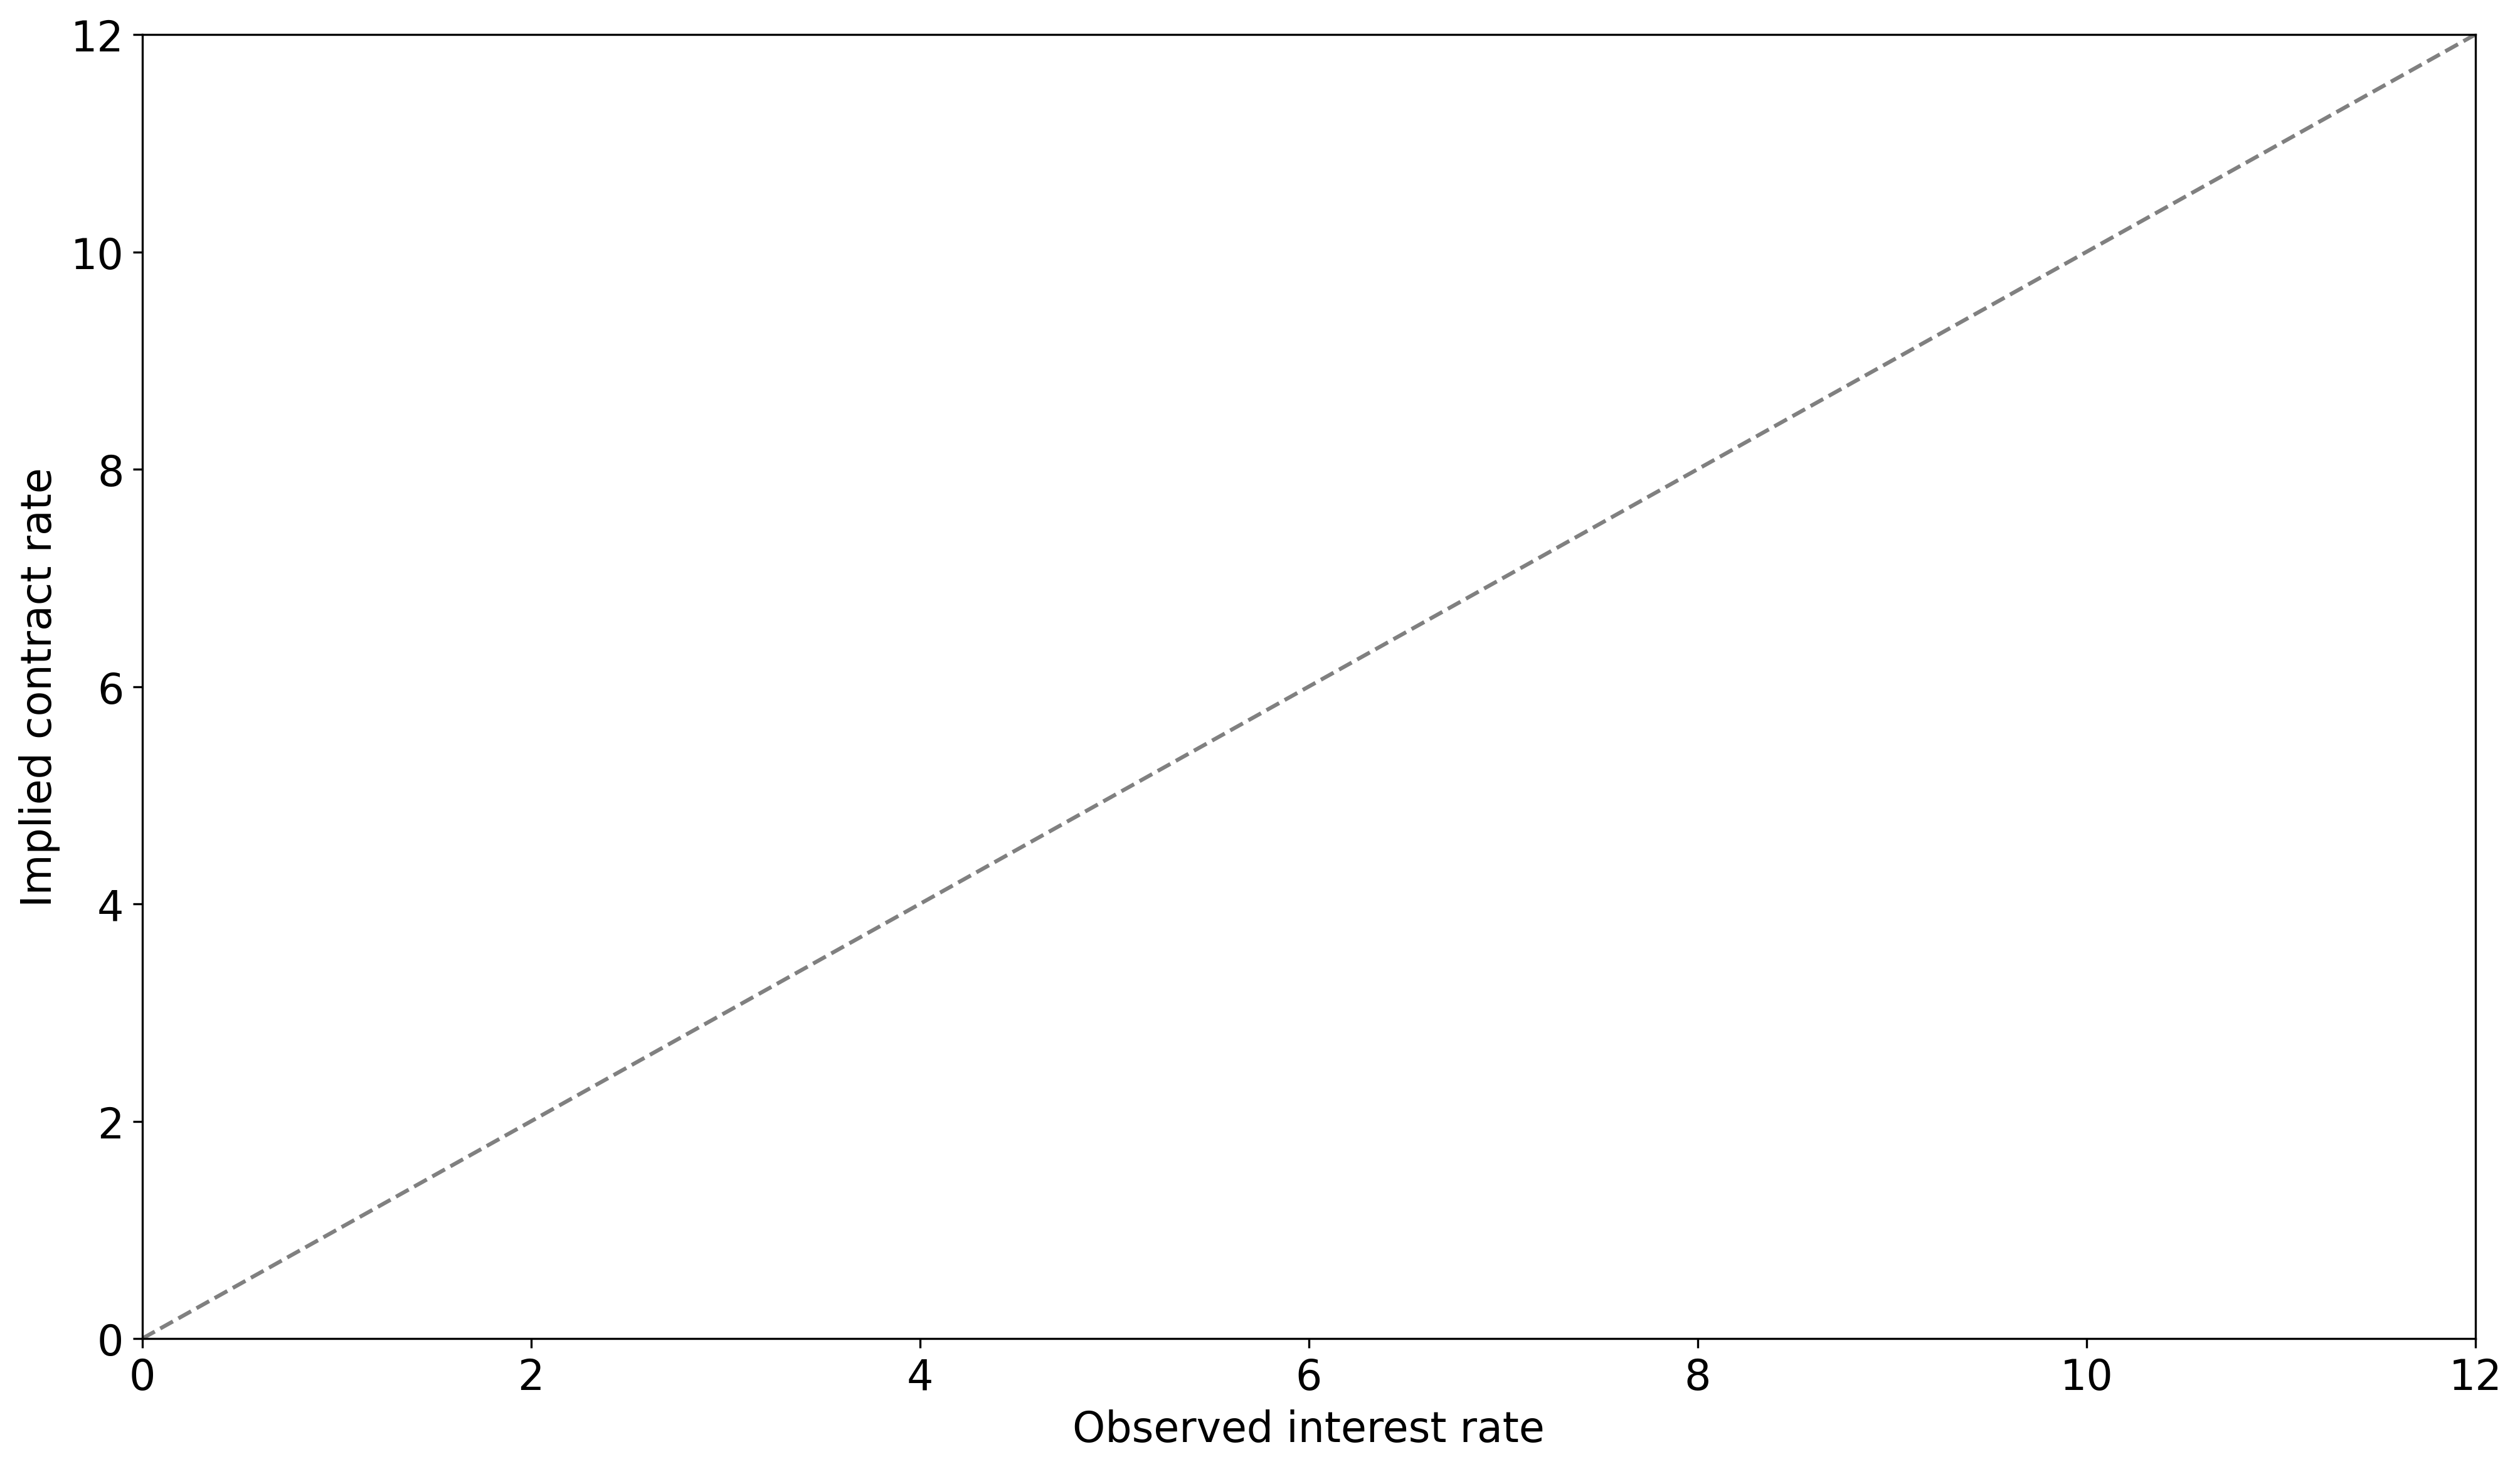

In [41]:
print(results[['interest_rate_time', 'loan_rate']].describe().round(decimals=2))

plt.scatter('interest_rate_time', 'loan_rate', data=results)
plt.ylabel('Implied contract rate')
plt.xlabel('Observed interest rate')
plt.plot([0,12],[0,12], color='gray', linestyle='dashed')
plt.xlim((0,12))
plt.ylim((0,12))
plt.show()